## Setup

```julia 
using Pkg; Pkg.activate(joinpath(@__DIR__, ".."))
```

### Requirements -- *to run just once* -- 
```julia 
Pkg.develop(joinpath(@__DIR__, "..", ".."))
Pkg.add(["ADNLPModels", "Plots", "LaTeXStrings", "Printf", "LinearAlgebra", "NLPModels", "Random"])
```

In [1]:
using Pkg; Pkg.activate(joinpath(@__DIR__, ".."))
Pkg.status()

### Requirements -- *to run just once* -- IF not in the environment already
# Pkg.develop(joinpath(@__DIR__, "..", "..")) 
# Pkg.add(["ADNLPModels", "Plots", "LaTeXStrings", "Printf", "LinearAlgebra", "NLPModels", "Random"])
# Pkg.add(["ADNLPModels", "Plots", "LaTeXStrings", "Printf", "LinearAlgebra", "NLPModels", "Random", "PyPlot"])

  Activating project at `c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\notebooks`


Status `C:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\notebooks\Project.toml`
  [54578032] ADNLPModels v0.8.13
  [b964fa9f] LaTeXStrings v1.4.0
  [a4795742] NLPModels v0.21.12
  [91a5bcdd] Plots v1.41.6
  [d330b81b] PyPlot v2.11.6
  [b2e96d2e] TrustRegionRadius v0.1.0 `c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\notebooks\Saddle\..\..`
  [37e2e46d] LinearAlgebra v1.11.0
  [de0858da] Printf v1.11.0
  [9a3f8284] Random v1.11.0


# What this notebook checks about the package

Every table and figure is produced by `tr_solve`, so the notebook doubles as an end-to-end
test on a problem with four known critical points and an exactly known Hessian:

| assertion | what it pins down |
|:--|:--|
| the critical-point table matches `hess` | the analytic problem, before any solver runs |
| `reports_negative_curvature` matches which models escape saddles | the trait, and the models honouring it |
| `cg_iters == 1`, `cos_cauchy ≈ 1` at small $\mu_{\max}$ | `cg_step_info`, and the Cauchy-point degeneration |
| `SPDTarget` raises exactly where $\varphi \geq 0$ | the lens condition, reported as `:exception` |
| $\tau = \|g\|$ over PSD models, $\tau > \|g\|$ over `ExactHessian` | `SecondOrder` and `criticality` |
| `:second_order` at the origin, `:first_order` at the saddle without $\tau$ | the stopping tests, including their limits |

# Trust-region configurations and the limit point

Which critical point a trust-region run converges to is decided by **all three axes** — the
radius mechanism, the model Hessian and the subproblem solver — and by their interaction, not
by any one of them alone.

The test function has four critical points of three different kinds, so the question has a
sharp answer:

$$f(p) = p_1^4 - p_1^3 + \left(\tfrac14 - \tfrac{p_1}{2}\right)p_2^2 + \tfrac{p_2^4}{4}$$

| point | kind |
|:--|:--|
| $(0,0)$ | **degenerate**: $\nabla^2 f$ singular and positive *semi*definite |
| $(0.75, 0)$ | **non-degenerate saddle**: $\lambda_{\min} = -0.25$ |
| $\left(\tfrac{1+\sqrt5}{4}, \pm\sqrt{\tfrac{\sqrt5-1}{4}}\right)$ | two local minima |

Everything below runs through `TrustRegionRadius.jl`. There is no local trust-region loop, no
local radius rule, no local subproblem solver and no local model Hessian: `tr_solve` does the
iterating and `stats.solver_specific` supplies every number that is plotted or tabulated.

### Structure worth noting

The second gradient component factors as

$$(\nabla f)_2 = y\left(y^2 - x + \tfrac12\right),$$

so it vanishes identically on $\{y=0\}$: **the line $y=0$ is invariant** under the gradient flow
$\dot z = -\nabla f(z)$. That line is exactly the stable manifold of the saddle $(3/4,0)$, of
codimension one and hence of measure zero — so the gradient flow from a *generic* point does not
reach the saddle. Any run that lands there must have been *steered* by the model.

At the origin $\nabla^2 f = \operatorname{diag}(0, 1/2)$ is singular and positive semidefinite, so
the second-order criticality measure $\tau(x) = \max\{\|g\|, -\lambda^-\}$ **vanishes** there. Yet
$f(x,0) = x^3(x-1) < 0$ for small $x>0$, so the origin is *not* a local minimiser: $\tau$ certifies
a point that second-order theory should reject.

In [2]:
using TrustRegionRadius
using ADNLPModels
using LinearAlgebra, Printf
using Plots

gr()
default(fontfamily = "Computer Modern", framestyle = :box, grid = true, gridalpha = 0.25,
        legendfontsize = 7, guidefontsize = 9, tickfontsize = 7, titlefontsize = 9,
        linewidth = 1.2, markersize = 2.5, size = (700, 400))

## 1. The problem

`f`, `grad` and `hess` are kept in closed form: they are what the critical-point table and the
phase portraits are computed from, and having the exact Hessian is what lets $\lambda_{\min}$
be reported without an estimate.

`tr_solve` needs an `AbstractNLPModel`, so the same `f` is wrapped in an `ADNLPModel`. That is
the only object the solver sees.

> If `grad`/`hess` collide with `NLPModels` exports in your session, either drop
> `using NLPModels` or rename these to `∇f`/`∇²f`. Nothing below calls the `NLPModels`
> versions directly — `tr_solve` handles all model evaluation.

In [3]:
# ---------------------------------------------------------------- test function
f(p) = p[1]^4 - p[1]^3 + (0.25 - p[1]/2)*p[2]^2 + p[2]^4/4

grad(p) = [4p[1]^3 - 3p[1]^2 - p[2]^2/2,
           p[2]^3 + 2p[2]*(0.25 - p[1]/2)]

hess(p) = [6p[1]*(2p[1]-1)   -p[2];
           -p[2]             (-p[1] + 3p[2]^2 + 0.5)]

# the same f, as the model the solver actually sees
make_nlp(x0 = X0_DEFAULT) = ADNLPModel(f, collect(float.(x0)), name = "quartic")

make_nlp (generic function with 2 methods)

In [4]:
# ---------------------------------------------------------------- critical points
const ORIGIN = [0.0, 0.0]                                   # degenerate, singular, PSD
const SADDLE = [0.75, 0.0]                                  # nonsingular saddle
const MINP   = [(1+sqrt(5))/4,  sqrt((sqrt(5)-1)/4)]        # local minimum
const MINM   = [(1+sqrt(5))/4, -sqrt((sqrt(5)-1)/4)]        # local minimum

const X0_DEFAULT = [-0.5, 0.6]

const CRITPTS = [("origin",  ORIGIN), ("saddle", SADDLE),
                 ("min+",    MINP),   ("min-",   MINM)]

println("Critical points of f\n")
@printf("%-8s %-22s %12s %12s %22s\n", "name", "x", "f(x)", "||grad||", "eig(hess)")
println("-"^80)
for (nm, p) in CRITPTS
    w = eigvals(Symmetric(hess(p)))
    @printf("%-8s (%+.6f, %+.6f) %12.8f %12.2e   (%+.5f, %+.5f)\n",
            nm, p[1], p[2], f(p), norm(grad(p)), w[1], w[2])
end

Critical points of f

name     x                              f(x)     ||grad||              eig(hess)
--------------------------------------------------------------------------------
origin   (+0.000000, +0.000000)   0.00000000     0.00e+00   (-0.00000, +0.50000)
saddle   (+0.750000, +0.000000)  -0.10546875     0.00e+00   (-0.25000, +2.25000)
min+     (+0.809017, +0.555893)  -0.12500000     3.93e-17   (+0.49469, +3.12334)
min-     (+0.809017, -0.555893)  -0.12500000     3.93e-17   (+0.49469, +3.12334)


In [5]:
# ---- standard parameters (change these and re-run) -----------------------
const ETA1, ETA2 = 0.1, 0.75        # acceptance / very-successful thresholds
const G1, G2, G3 = 0.25, 0.5, 2.0   # gamma_1, gamma_2, gamma_3
const ZETA       = 0.5              # R-DFO criticality threshold
const MU0, DELTA0 = 0.5, 1.0        # initial mu and radius
const MU_BAR     = 2.0              # cap for the bounded-mu variant of R-grad

const TOL, KMAX = 1e-9, 2000

(1.0e-9, 2000)

## 2. Axis 1 — radius mechanisms

Straight from the package. The factories exist so each run starts from a clean multiplier:
`RGrad` and `RGradCapped` carry a mutable $\mu$, and reusing one instance across
configurations would make the results depend on the order they were run in.

In [6]:
# Factories, so each run starts from a clean multiplier.
mk_delta()      = RDelta(     γ1 = G1, γ2 = G2, γ3 = G3)
mk_step()       = RStep(      γ1 = G1, γ2 = G2, γ3 = G3)
mk_dfo()        = RDFO(       γ1 = G1, γ2 = G2, γ3 = G3, ζ = ZETA)
mk_grad()       = RGrad(      γ1 = G1, γ2 = G2, γ3 = G3, μ = MU0)
mk_gradcapped() = RGradCapped(γ1 = G1, γ2 = G2, γ3 = G3, μ = MU0, μ_max = MU_BAR)

const RULES = [("R-delta", mk_delta), ("R-step", mk_step), ("R-DFO", mk_dfo),
               ("R-grad", mk_grad),   ("R-grad capped", mk_gradcapped)]

@printf("%-16s %-18s %s\n", "rule", "regime", "criticality-anchored")
for (nm, mk) in RULES
    r = mk()
    @printf("%-16s %-18s %s\n", nm, asymptotic_regime(r), is_criticality_anchored(r))
end

rule             regime             criticality-anchored
R-delta          bounded_below      false
R-step           step_summable      false
R-DFO            vanishing          true
R-grad           vanishing          true
R-grad capped    vanishing          true


## 3. Axes 2 and 3 — model Hessians and subproblem solvers

Also from the package. The column that decides this notebook's question is the last one:
**a model that cannot report negative curvature cannot escape a saddle**, whatever the radius
rule does.

In [7]:
const MODELS = [("true",       () -> ExactHessian()),
                ("SR1",        () -> SR1Model(mem = 10)),
                ("L-BFGS",     () -> LBFGSModel(mem = 5)),
                ("SPD→saddle", () -> SPDTarget(target = SADDLE))]

const SUBSOLVERS = [("Steihaug CG", () -> SteihaugCG()),
                    ("exact M-S",   () -> ExactMS()),
                    ("EigenPoint",  () -> EigenPoint(SteihaugCG()))]

@printf("%-14s %s\n", "model", "reports negative curvature")
for (nm, mk) in MODELS
    @printf("%-14s %s\n", nm, reports_negative_curvature(mk()))
end
println()
println("Only `true` and SR1 can report λ_min < 0. That is the whole content of §7:")
println("no radius mechanism repairs a model that cannot see the curvature it needs.")

model          reports negative curvature
true           true
SR1            true
L-BFGS         false
SPD→saddle     false

Only `true` and SR1 can report λ_min < 0. That is the whole content of §7:
no radius mechanism repairs a model that cannot see the curvature it needs.


## 4. Running a configuration

One call. `tr_solve` does the iterating; `stats.solver_specific` carries everything the
figures and tables need:

| key | meaning | length |
|:--|:--|:--|
| `:delta_trajectory` | $\Delta_k$ | $k+1$ |
| `:grad_trajectory` | $\|g_k\|$ | $k+1$ |
| `:obj_trajectory` | $f(x_k)$ | $k+1$ |
| `:ratio_trajectory` | $\rho_k$ | $k$ |
| `:step_trajectory` | $\|s_k\|$ | $k$ |
| `:active_trajectory` | $\|s_k\| = \Delta_k$ | $k$ |
| `:accepted_trajectory` | $\rho_k \ge \eta$ | $k$ |
| `:lambda_min_trajectory`, `:tau_trajectory` | only when a curvature estimate was requested | $k+1$ |

The one thing the trace does not carry is the **iterate path**, which the phase portraits in
§8 need. `tr_solve` takes a `callback`, and the solver sets `stats.solution` immediately
before calling it, so `solve_path` below collects $x_k$ that way. That is a package facility,
not a reimplementation — the iteration is still entirely `tr_solve`'s.

In [8]:
"Run one configuration. Returns the GenericExecutionStats from tr_solve, unchanged."
function run_cfg(; rule, model = ExactHessian(), subsolver = SteihaugCG(),
                   x0 = X0_DEFAULT, tol = TOL, tol_H = -1.0, kmax = KMAX,
                   Δ0 = DELTA0, η = ETA1)
    return tr_solve(make_nlp(x0); rule = rule, model = model, subsolver = subsolver,
                    params = TRParams(η = η, η1 = ETA1, η2 = ETA2, Δ0 = Δ0,
                                      tol = tol, tol_H = tol_H, max_iterations = kmax),
                    trace = true)
end

"Same, plus the iterate path collected through the solver's callback."
function solve_path(; x0 = X0_DEFAULT, kwargs...)
    xs = [collect(float.(x0))]
    st = tr_solve(make_nlp(x0);
                  params = TRParams(η = get(kwargs, :η, ETA1), η1 = ETA1, η2 = ETA2,
                                    Δ0 = get(kwargs, :Δ0, DELTA0),
                                    tol = get(kwargs, :tol, TOL),
                                    tol_H = get(kwargs, :tol_H, -1.0),
                                    max_iterations = get(kwargs, :kmax, KMAX)),
                  rule      = kwargs[:rule],
                  model     = get(kwargs, :model, ExactHessian()),
                  subsolver = get(kwargs, :subsolver, SteihaugCG()),
                  trace = true,
                  callback = (_n, _s, stats) -> push!(xs, copy(stats.solution)))
    return st, xs
end

"Classify a limit point by distance to the four known critical points."
function which_crit(x; tol = 1e-4)
    best, bd = "other", Inf
    for (nm, p) in CRITPTS
        d = norm(x .- p); d < bd && (bd = d; best = nm)
    end
    return bd < tol ? best : "other"
end

# `tail_active` used to be defined here, hand-rolled, with
#     k0 = max(1, floor(Int, 0.9 * length(a)))
# which is off by one against the package: at n = 41 it takes six points where
# `active_fraction` takes five, because floor(0.9n) is the last index before the
# tail and the tail starts at floor(0.9n) + 1. Use the package, which does the
# slice once and correctly, and takes `stats` rather than `stats.solver_specific`.

let st = run_cfg(rule = mk_delta(), subsolver = ExactMS())
    ss = st.solver_specific
    @printf("status %s after %d iterations → %s\n", st.status, st.iter, which_crit(st.solution))
    @printf("  ‖g‖ = %.3e   Δ_end = %.3e   tail active = %.2f\n",
            st.dual_feas, ss[:delta_trajectory][end], active_fraction(st; tail = 0.1))
end

status first_order after 16 iterations → origin
  ‖g‖ = 5.032e-10   Δ_end = 6.554e+04   tail active = 0.00


## 5. The configuration matrix

Every (rule × model) pair, with the exact subproblem solver held fixed so the model is the
only thing varying alongside the radius rule.

The limit column is the finding. Nothing in `status`, `‖g‖` or the iteration count
distinguishes a run that reached a minimum from one that reached the saddle — every one of
them satisfies its own first-order test.

In [9]:
function config_matrix(; subsolver = () -> ExactMS(), x0 = X0_DEFAULT, tol_H = -1.0)
    @printf("%-16s %-13s %13s %7s %11s %10s %11s\n",
            "rule", "model", "status", "iters", "limit", "f(x*)", "tail act.")
    println("-"^88)
    for (rname, mkr) in RULES, (mname, mkm) in MODELS
        local st
        try
            st = run_cfg(rule = mkr(), model = mkm(), subsolver = subsolver(),
                         x0 = x0, tol_H = tol_H)
        catch err
            @printf("%-16s %-13s %13s\n", rname, mname, "DomainError")
            continue
        end
        ss = st.solver_specific
        @printf("%-16s %-13s %13s %7d %11s %10.6f %11.2f\n",
                rname, mname, string(st.status), st.iter,
                which_crit(st.solution), st.objective, active_fraction(st; tail = 0.1))
    end
end

config_matrix()

rule             model                status   iters       limit      f(x*)   tail act.
----------------------------------------------------------------------------------------
R-delta          true            first_order      16      origin   0.000000        0.00
R-delta          SR1             first_order      12        min+  -0.125000        0.00
R-delta          L-BFGS          first_order      20        min+  -0.125000        0.00
R-delta          SPD→saddle      first_order       2      saddle  -0.105469        0.00
R-step           true            first_order      16      origin   0.000000        0.00
R-step           SR1                 stalled      20        min+  -0.125000        1.00
R-step           L-BFGS              stalled      28        min+  -0.125000        1.00
R-step           SPD→saddle      first_order       2      saddle  -0.105469        0.00
R-DFO            true            first_order      16      origin   0.000000        0.00
R-DFO            SR1           

## 6. Small $\mu_{\max}$ and truncated CG: R-grad degenerates to gradient descent

`RGradCapped` bounds $\mu_k \le \mu_{\max}$, which the asymptotic theory needs. The cost is
real: with a truncated-CG subsolver a small $\mu_{\max}$ makes CG stop on its **first**
iteration, and the first CG direction is $-g$ — so the returned step is exactly the Cauchy
point and the model Hessian has had no influence on the direction at all.

`cg_step_info` is the package's diagnostic for this. `cg_iters == 1 && active` together with
`cos_cauchy ≈ 1` certify the degeneration, and nothing in $\rho$, $\|g\|$ or the radius trace
shows it.

In [10]:
const MU_SWEEP = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 4.0, 8.0, 128.0]

@printf("%8s %13s %7s %11s %10s %10s %11s\n",
        "μ_max", "status", "iters", "limit", "cauchy %", "cos(s,−g)", "tail act.")
println("-"^82)
for μm in MU_SWEEP
    st = run_cfg(rule = RGradCapped(γ1 = G1, γ2 = G2, γ3 = G3, μ = min(MU0, μm), μ_max = μm),
                 model = ExactHessian(), subsolver = SteihaugCG())
    ss = st.solver_specific
    # Over the run, not at iteration 0. This used to call cg_step_info at
    # X0_DEFAULT with Δ_0, so every row reported the same probe at the same point
    # and the column was constant at cg_iters = 2, cos = 0.877285 for μ̄ ≥ 0.3.
    # The solver now records both quantities for the iterations that happened.
    cgit = ss[:cg_iters_trajectory]
    cosc = ss[:cos_cauchy_trajectory]
    frac = hypotheses_report(st).cauchy_fraction
    direct = isempty(cgit) ? NaN : count(==(1), cgit) / length(cgit)
    @printf("%8.2f %13s %7d %11s %9.1f%% %10.6f %11.2f\n",
            μm, string(st.status), st.iter, which_crit(st.solution),
            100 * frac, isempty(cosc) ? NaN : cosc[end],
            active_fraction(st; tail = 0.1))
    # cauchy_fraction is cos(s,−g) ≈ 1 within 1e-12; the direct count is on
    # cg_iters == 1. They answer the same question two ways and should agree.
    isnan(direct) || abs(direct - frac) < 0.05 ||
        @warn "cauchy_fraction and the cg_iters count disagree" μm frac direct
end
println()
println("cauchy % is the fraction of the run on which the step was the Cauchy point,")
println("i.e. on which the model Hessian did not influence the direction at all. A small")
println("cap holds Δ_k below the Newton step everywhere, so CG truncates on its first")
println("iteration and the method is gradient descent in disguise. Read down the column:")
println("the degeneration is a property of the whole run, not of its first iterate.")

   μ_max        status   iters       limit   cauchy %  cos(s,−g)   tail act.
----------------------------------------------------------------------------------
    0.01      max_iter    2000       other     100.0%   1.000000        1.00
    0.05      max_iter    2000       other     100.0%   1.000000        1.00
    0.10      max_iter    2000       other     100.0%   1.000000        1.00
    0.30      max_iter    2000       other     100.0%   1.000000        1.00
    0.50      max_iter    2000       other      99.9%   1.000000        1.00
    1.00      max_iter    2000       other      99.9%   1.000000        1.00
    2.00      max_iter    2000      origin      99.9%   1.000000        1.00
    4.00      max_iter    2000      origin      48.9%   1.000000        1.00
    8.00   first_order    1678      origin      48.2%   0.728476        1.00
  128.00   first_order      85      origin       8.2%   0.396954        1.00

cauchy % is the fraction of the run on which the step was the Cauchy 

┌ Warning: cauchy_fraction and the cg_iters count disagree
│   μm = 4.0
│   frac = 0.4885
│   direct = 0.3345
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\notebooks\Saddle\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X25sZmlsZQ==.jl:25
┌ Warning: cauchy_fraction and the cg_iters count disagree
│   μm = 8.0
│   frac = 0.48152562574493446
│   direct = 0.331942789034565
└ @ Main c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\notebooks\Saddle\jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X25sZmlsZQ==.jl:25


## 7. R-DFO: the $\zeta$ sweep

`RDFO` expands only when $\Delta_k \le \zeta\|g_k\|$. The guarantee needs
$\zeta > \bar\kappa = 4/\lambda^\ast_{\min}$ — a property of the **solution**, so it cannot be
chosen in advance. Below the threshold the constraint binds for ever and the method degrades
to linear convergence while every first-order diagnostic looks healthy.

`tail_active` is the observable: it is the fraction of late iterations on which
$\|s_k\| = \Delta_k$. A value pinned at 1 is the constraint never releasing.

In [11]:
const ZETA_SWEEP = [0.1, 0.5, 1.0, 2.0, 5.0, 20.0]

for (mname, mkm) in [("true", () -> ExactHessian()), ("SR1", () -> SR1Model(mem = 10)),
                     ("L-BFGS", () -> LBFGSModel(mem = 5))]
    println("\nmodel = ", mname)
    @printf("%8s %13s %7s %11s %11s %12s\n",
            "ζ", "status", "iters", "limit", "tail act.", "Δ_end")
    println("-"^68)
    for ζ in ZETA_SWEEP
        st = run_cfg(rule = RDFO(γ1 = G1, γ2 = G2, γ3 = G3, ζ = ζ),
                     model = mkm(), subsolver = SteihaugCG())
        ss = st.solver_specific
        @printf("%8.2f %13s %7d %11s %11.2f %12.3e\n",
                ζ, string(st.status), st.iter, which_crit(st.solution),
                active_fraction(st; tail = 0.1), ss[:delta_trajectory][end])
    end
end


model = true
       ζ        status   iters       limit   tail act.        Δ_end
--------------------------------------------------------------------
    0.10   first_order      16      origin        0.00    1.526e-05
    0.50   first_order      16      origin        0.00    1.526e-05
    1.00   first_order      16      origin        0.00    6.104e-05
    2.00   first_order      16      origin        0.00    6.104e-05
    5.00   first_order      16      origin        0.00    2.441e-04
   20.00   first_order      16      origin        0.00    2.441e-04

model = SR1
       ζ        status   iters       limit   tail act.        Δ_end
--------------------------------------------------------------------
    0.10       stalled     254        min+        1.00    4.547e-13
    0.50   first_order      11        min+        0.00    9.766e-04
    1.00   first_order      12        min+        0.00    3.906e-03
    2.00   first_order      12        min+        0.00    3.906e-03
    5.00   first_or

## 8. The constructed SPD model: steered to a saddle

`SPDTarget` builds a model Hessian that is positive definite **and** whose unconstrained
minimiser is pinned to `target`. Point it at the saddle and every hypothesis of the
first-order theory holds — every $\rho$ is successful, $\|g\| \to 0$ — and the limit is a
saddle. The failure is the model, and no radius rule repairs it.

The construction exists only where $\varphi(x) = g(x)^\top(\text{target} - x) < 0$, i.e. where
the target lies downhill. `phi_target` queries it directly, and the solver raises a
`DomainError` elsewhere, which `tr_solve` reports as `:exception` rather than silently
substituting something else.

In [12]:
println("Every radius rule, over an SPD model aimed at the saddle:\n")
@printf("%-16s %13s %7s %11s %12s\n", "rule", "status", "iters", "limit", "‖x*−saddle‖")
println("-"^64)
for (rname, mkr) in RULES
    st = run_cfg(rule = mkr(), model = SPDTarget(target = SADDLE), subsolver = SteihaugCG(),
                 x0 = X0_DEFAULT)
    @printf("%-16s %13s %7d %11s %12.3e\n", rname, string(st.status), st.iter,
            which_crit(st.solution), norm(st.solution .- SADDLE))
end

println("\nWhere the construction exists: φ(x) = g(x)ᵀ(target − x) < 0")
@printf("%-22s %12s %s\n", "x", "φ(x)", "SPD model exists?")
println("-"^54)
for x in ([-0.5, 0.6], [0.0, 0.5], [0.5, 0.1], [0.9, 0.0], MINP)
    φ = dot(grad(x), SADDLE .- x)
    @printf("(%+.3f, %+.3f)       %12.5f %s\n", x[1], x[2], φ, φ < 0 ? "yes" : "no — DomainError")
end

Every radius rule, over an SPD model aimed at the saddle:

rule                    status   iters       limit  ‖x*−saddle‖
----------------------------------------------------------------
R-delta            first_order       2      saddle    2.776e-17
R-step             first_order       2      saddle    2.776e-17
R-DFO              first_order       2      saddle    2.776e-17
R-grad             first_order       5      saddle    6.939e-17
R-grad capped      first_order       5      saddle    6.939e-17

Where the construction exists: φ(x) = g(x)ᵀ(target − x) < 0
x                              φ(x) SPD model exists?
------------------------------------------------------
(-0.500, +0.600)           -2.27710 yes
(+0.000, +0.500)           -0.28125 yes
(+0.500, +0.100)           -0.06385 yes
(+0.900, +0.000)           -0.07290 yes
(+0.809, +0.556)            0.00000 no — DomainError


## 9. Figures, from the trace

Everything plotted below is read out of `stats.solver_specific`. Nothing is recomputed.

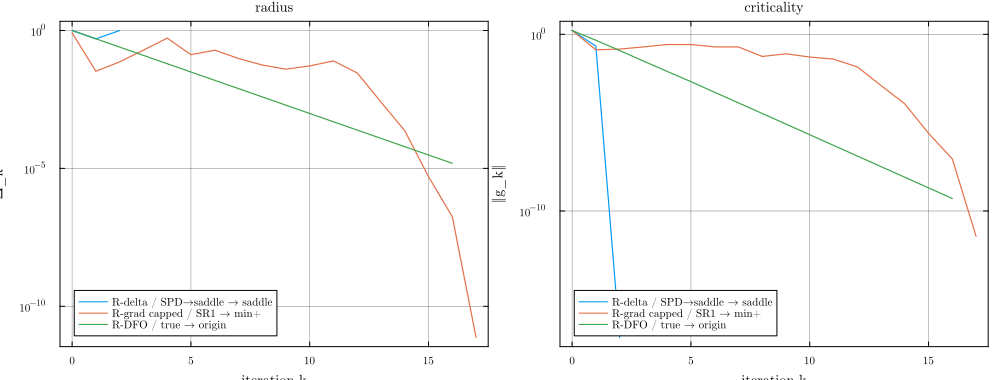

In [13]:
# --- radius and gradient trajectories, three configurations with different limits ---
runs = [("R-delta / SPD→saddle", mk_delta,      () -> SPDTarget(target = SADDLE), :cg),
        ("R-grad capped / SR1",  mk_gradcapped, () -> SR1Model(mem = 10),         :exact),
        ("R-DFO / true",         mk_dfo,        () -> ExactHessian(),             :cg)]

pΔ = plot(xlabel = "iteration k", ylabel = "Δ_k", yscale = :log10,
          title = "radius", legend = :bottomleft)
pg = plot(xlabel = "iteration k", ylabel = "‖g_k‖", yscale = :log10,
          title = "criticality", legend = :bottomleft)

for (label, mkr, mkm, sub) in runs
    st = run_cfg(rule = mkr(), model = mkm(),
                 subsolver = sub === :cg ? SteihaugCG() : ExactMS())
    ss = st.solver_specific
    lab = @sprintf("%s → %s", label, which_crit(st.solution))
    plot!(pΔ, 0:length(ss[:delta_trajectory])-1, max.(ss[:delta_trajectory], 1e-300); label = lab)
    plot!(pg, 0:length(ss[:grad_trajectory])-1,  max.(ss[:grad_trajectory],  1e-300); label = lab)
end
plot(pΔ, pg; layout = (1, 2), size = (1000, 380))

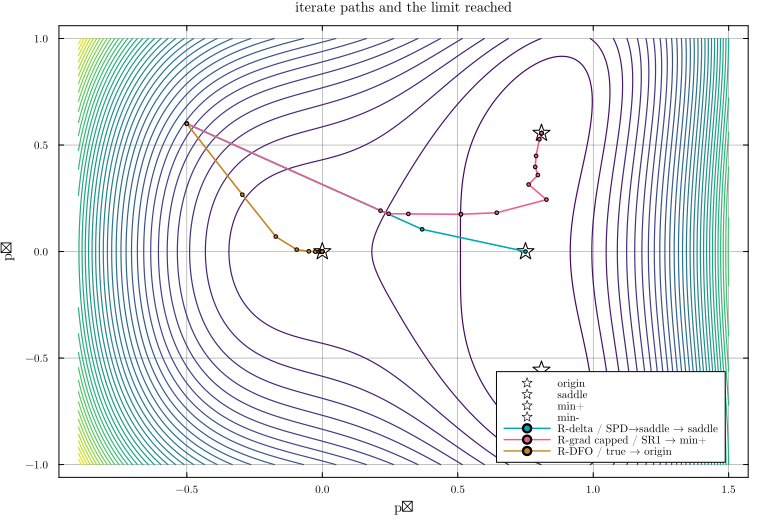

GKS: glyph missing from current font: 8321
GKS: glyph missing from current font: 8322
GKS: glyph missing from current font: 8321
GKS: glyph missing from current font: 8322
GKS: glyph missing from current font: 8321
GKS: glyph missing from current font: 8321
GKS: glyph missing from current font: 8321
GKS: glyph missing from current font: 8322
GKS: glyph missing from current font: 8322
GKS: glyph missing from current font: 8322
GKS: glyph missing from current font: 8321
GKS: glyph missing from current font: 8322
GKS: glyph missing from current font: 8321
GKS: glyph missing from current font: 8322
GKS: glyph missing from current font: 8321
GKS: glyph missing from current font: 8321
GKS: glyph missing from current font: 8321
GKS: glyph missing from current font: 8322
GKS: glyph missing from current font: 8322
GKS: glyph missing from current font: 8322
GKS: glyph missing from current font: 8321
GKS: glyph missing from current font: 8322
GKS: glyph missing from current font: 8321
GKS: glyph 

In [14]:
# --- iterate paths over the contour, via the solver callback ---
xs_grid = range(-0.9, 1.5; length = 320)
ys_grid = range(-1.0, 1.0; length = 320)
Z = [f([x, y]) for y in ys_grid, x in xs_grid]

pc = contour(xs_grid, ys_grid, Z; levels = 40, c = :viridis, colorbar = false,
             xlabel = "p₁", ylabel = "p₂", title = "iterate paths and the limit reached",
             size = (760, 520))
for (nm, p) in CRITPTS
    scatter!(pc, [p[1]], [p[2]]; m = :star5, ms = 9, c = :white,
             markerstrokecolor = :black, label = nm)
end
for (label, mkr, mkm, sub) in runs
    st, xs = solve_path(rule = mkr(), model = mkm(),
                        subsolver = sub === :cg ? SteihaugCG() : ExactMS())
    P = reduce(hcat, xs)
    plot!(pc, P[1, :], P[2, :]; lw = 1.6, marker = :circle, ms = 2,
          label = @sprintf("%s → %s", label, which_crit(st.solution)))
end
pc

## 10. Second-order anchoring, and where it stops helping

Everything above measures criticality by $\|g_k\|$, which vanishes at **every** critical point.
The second-order measure

$$\tau_k = \max\{\|g_k\|,\; -\lambda_{\min}(B_k)\}$$

vanishes only where the model is genuinely second-order critical. `SecondOrder` is a wrapper
that forwards `update_radius!` to the rule it wraps and overrides only `criticality`, so
`RGradTau` **is** `RGrad` with a different anchor — which makes the comparison clean.

This function is unusually good at showing what $\tau$ does and does not repair, because its
two non-minimising critical points fail in different ways.

In [15]:
println("τ = max{‖g‖, −λ_min(∇²f)} at the critical points\n")
@printf("%-8s %-22s %10s %10s %10s   %s\n",
        "name", "x", "‖g‖", "λ_min", "τ", "what τ does")
println("-"^92)
for (nm, p) in CRITPTS
    gn = norm(grad(p)); λ = eigvals(Symmetric(hess(p)))[1]; τ = max(gn, -λ)
    @printf("%-8s (%+.4f, %+.4f) %10.2e %10.4f %10.4f   %s\n", nm, p[1], p[2], gn, λ, τ,
            τ > 1e-12 ? "keeps Δ alive" : "collapses, exactly as ‖g‖ does")
end

τ = max{‖g‖, −λ_min(∇²f)} at the critical points

name     x                             ‖g‖      λ_min          τ   what τ does
--------------------------------------------------------------------------------------------
origin   (+0.0000, +0.0000)   0.00e+00    -0.0000     0.0000   collapses, exactly as ‖g‖ does
saddle   (+0.7500, +0.0000)   0.00e+00    -0.2500     0.2500   keeps Δ alive
min+     (+0.8090, +0.5559)   3.93e-17     0.4947     0.0000   collapses, exactly as ‖g‖ does
min-     (+0.8090, -0.5559)   3.93e-17     0.4947     0.0000   collapses, exactly as ‖g‖ does


### The result worth stating plainly

$\tau$ repairs the **saddle** and is powerless at the **origin**.

- At $(0.75,0)$ the Hessian is $\mathrm{diag}(2.25,-0.25)$, so $\tau = 0.25 > 0$: the radius
  stays at the scale of the curvature actually available, and a subsolver that can move along
  $v_{\min}$ escapes.
- At the origin the Hessian is $\mathrm{diag}(0,\,0.5)$ — positive *semi*definite,
  $\lambda_{\min} = 0$ — so $\tau = 0$ and the $\tau$-anchored radius collapses exactly as the
  $\|g\|$-anchored one does.

The origin is a genuine second-order critical point: it satisfies the second-order **necessary**
conditions, and no second-order mechanism can detect that it is not a minimiser. Along
$p_2 = 0$, $f = p_1^3(p_1-1) < 0$ for small $p_1 > 0$ — the descent direction is **third
order**, invisible to $\tau$.

The $p_1$-axis is invariant ($\nabla_2 f = p_2(p_2^2 + \tfrac12 - p_1)$ vanishes at $p_2 = 0$),
so a start on the axis runs exactly into one of the two axis critical points, and the sign of
$p_1$ decides which. No tuning is needed to provoke either failure.

In [16]:
const X0_TO_ORIGIN = [-0.5, 0.0]     # f'(p₁) = p₁²(4p₁−3) < 0 ⇒ flow climbs to the ORIGIN
const X0_TO_SADDLE = [ 0.3, 0.0]     #                          ⇒ flow climbs to the SADDLE
const TOL_H = 1e-6

const PROBES = [
  ("RGrad   ‖g‖  Steihaug",   () -> RGrad(μ = 1.0),    () -> SteihaugCG(),             -1.0),
  ("RGrad   τ    Steihaug",   () -> RGradTau(μ = 1.0), () -> SteihaugCG(),             TOL_H),
  ("RGrad   τ    EigenPoint", () -> RGradTau(μ = 1.0), () -> EigenPoint(SteihaugCG()), TOL_H),
  ("RDFO    ‖g‖  Steihaug",   () -> RDFO(ζ = 1.0),     () -> SteihaugCG(),             -1.0),
  ("RDFO    τ    EigenPoint", () -> RDFOTau(ζ = 1.0),  () -> EigenPoint(SteihaugCG()), TOL_H),
]

for (tag, x0) in (("→ SADDLE  (λ_min = −0.25, non-degenerate)", X0_TO_SADDLE),
                  ("→ ORIGIN  (λ_min = 0, degenerate)",         X0_TO_ORIGIN))
    println("\n", "="^94)
    println("start x₀ = ", x0, "   ", tag)
    println("="^94)
    @printf("%-26s %14s %7s %10s %12s %12s\n",
            "configuration", "status", "iters", "limit", "f(x*)", "Δ_end")
    println("-"^94)
    for (label, mkr, mks, tH) in PROBES
        st = run_cfg(rule = mkr(), model = ExactHessian(), subsolver = mks(),
                     x0 = x0, tol_H = tH, tol = 1e-8, kmax = 5_000)
        ss = st.solver_specific
        @printf("%-26s %14s %7d %10s %12.6f %12.3e\n", label, string(st.status), st.iter,
                which_crit(st.solution), st.objective, ss[:delta_trajectory][end])
    end
end


start x₀ = [0.3, 0.0]   → SADDLE  (λ_min = −0.25, non-degenerate)
configuration                      status   iters      limit        f(x*)        Δ_end
----------------------------------------------------------------------------------------------
RGrad   ‖g‖  Steihaug         first_order       8     saddle    -0.105469    2.998e-14
RGrad   τ    Steihaug             stalled       9     saddle    -0.105469    1.250e-01
RGrad   τ    EigenPoint      second_order      13       min-    -0.125000    3.106e-14
RDFO    ‖g‖  Steihaug         first_order       7     saddle    -0.105469    1.562e-02
RDFO    τ    EigenPoint      second_order      12       min-    -0.125000    1.562e-02

start x₀ = [-0.5, 0.0]   → ORIGIN  (λ_min = 0, degenerate)
configuration                      status   iters      limit        f(x*)        Δ_end
----------------------------------------------------------------------------------------------
RGrad   ‖g‖  Steihaug         first_order      14     origin     0.000000 

### Reading the two tables

**From $(0.3,0)$, into the non-degenerate saddle.** The $\|g\|$-anchored rules stop there and
report `:first_order` — correctly by their own test, since $\|g\| = 0$ at a saddle just as at
a minimum. It is the test that is wrong, not the run. Under $\tau$ the radius survives, and
with `EigenPoint` supplying a step along $v_{\min}$ the run leaves and reaches a minimiser,
reporting `:second_order`.

The middle row matters: **$\tau$ with plain Steihaug is not enough.** $\tau$ keeps the radius
positive; it does not make the step go anywhere. Steihaug stops at the first negative-curvature
direction the CG recurrence happens to reach, and its guaranteed decrease carries no
$|\lambda_{\min}|\Delta^2$ term. `EigenPoint` compares the inner step against
$\pm\Delta v_{\min}$ and keeps the better, which is what supplies that term. The measure and
the subsolver are independent requirements.

**From $(-0.5,0)$, into the degenerate origin.** Every row lands on the origin. $\tau = 0$
there, so the $\tau$-rules behave identically to their $\|g\|$-twins — and the runs with
`tol_H > 0` report `:second_order`, which is *true*:
$\lambda_{\min}(\nabla^2 f) = 0 \geq -\texttt{tol\_H}$. The status is correct and the point is
not a minimiser.

That is the boundary of what the machinery claims. `:second_order` certifies the second-order
**necessary** conditions on the **model**; it is not a certificate of local minimality, and on
a degenerate critical point the two come apart.

In [17]:
# The third ingredient: the model has to be able to SEE the curvature.
println("τ-anchoring over models that cannot report negative curvature\n")
@printf("%-16s %14s %7s %10s %16s %12s\n",
        "model", "status", "iters", "limit", "min λ_min(B)", "τ ≡ ‖g‖?")
println("-"^80)
for (mname, mkm) in [("ExactHessian", () -> ExactHessian()),
                     ("SR1Model",     () -> SR1Model(mem = 10)),
                     ("LBFGSModel",   () -> LBFGSModel(mem = 5))]
    st = run_cfg(rule = RGradTau(μ = 1.0), model = mkm(),
                 subsolver = EigenPoint(SteihaugCG()),
                 x0 = X0_TO_SADDLE, tol_H = TOL_H, tol = 1e-8, kmax = 5_000)
    λ = get(st.solver_specific, :lambda_min_trajectory, Float64[])
    mn = isempty(λ) ? NaN : minimum(λ)
    @printf("%-16s %14s %7d %10s %16.4f %12s\n", mname, string(st.status), st.iter,
            which_crit(st.solution), mn, mn >= 0 ? "yes — no-op" : "no")
end
println()
println("A model whose min λ_min is ≥ 0 never gave τ anything to work with: the τ-rule ran")
println("as its ‖g‖-twin, and any :second_order it reports certifies the MODEL, not f.")

τ-anchoring over models that cannot report negative curvature

model                    status   iters      limit     min λ_min(B)     τ ≡ ‖g‖?
--------------------------------------------------------------------------------
ExactHessian       second_order      13       min-          -0.7200           no
SR1Model           second_order       8     saddle           0.6567  yes — no-op
LBFGSModel         second_order       7     saddle           0.6567  yes — no-op

A model whose min λ_min is ≥ 0 never gave τ anything to work with: the τ-rule ran
as its ‖g‖-twin, and any :second_order it reports certifies the MODEL, not f.


┌ Warning: τ ≡ ‖g‖: this model is positive (semi)definite by construction, so λ_min(B) ≥ 0 always and the second-order machinery is a no-op. A :second_order status from this run certifies nothing about ∇²f. Use ExactHessian or SR1Model when the second-order question is the question.
│   model = LBFGSModel
└ @ TrustRegionRadius c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\src\Trust-region\common.jl:307


status second_order   limit min-   max τ/‖g‖ = 11.864   min λ_min(B) = -0.7200


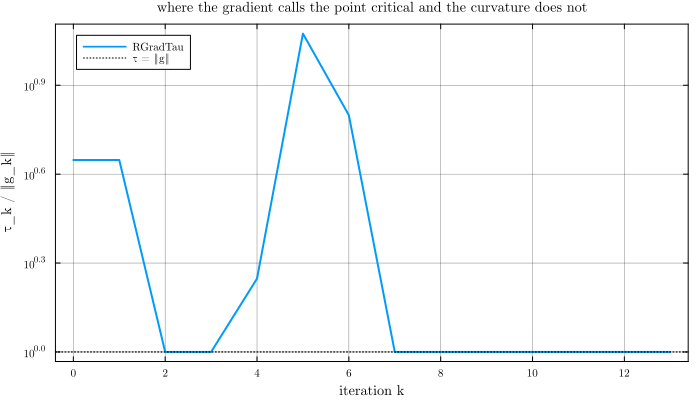

In [18]:
# τ_k against ‖g_k‖ along one run: where the two measures disagree.
st = run_cfg(rule = RGradTau(μ = 1.0), model = ExactHessian(),
             subsolver = EigenPoint(SteihaugCG()),
             x0 = X0_TO_SADDLE, tol_H = TOL_H, tol = 1e-8, kmax = 5_000)
ss = st.solver_specific
τ, g = ss[:tau_trajectory], ss[:grad_trajectory]
gap = τ ./ max.(g, 1e-300)

@printf("status %s   limit %s   max τ/‖g‖ = %.3f   min λ_min(B) = %.4f\n",
        st.status, which_crit(st.solution), maximum(gap),
        minimum(ss[:lambda_min_trajectory]))

p = plot(0:length(gap)-1, gap; yscale = :log10, lw = 2, legend = :topleft,
         xlabel = "iteration k", ylabel = "τ_k / ‖g_k‖", label = "RGradTau",
         title = "where the gradient calls the point critical and the curvature does not")
hline!(p, [1.0]; ls = :dot, c = :black, label = "τ = ‖g‖")

## 11. What the matrix shows

1. **The radius rule decides whether you can leave a saddle at all.** Under $\|g\|$-anchoring
   the radius collapses there and the run is trapped whatever the subsolver; under $\tau$ it
   does not.
2. **The subsolver decides whether you actually do.** $\tau$ + Steihaug keeps the radius alive
   with no reliable negative-curvature step.
3. **The model decides whether $\tau$ means anything.** Over `LBFGSModel` or `SPDTarget`,
   $\lambda_{\min}(B) \geq 0$ identically, so $\tau \equiv \|g\|$ and the whole apparatus is
   decoration — while still able to report `:second_order`.
4. **None of it helps at a degenerate critical point.** At the origin $\lambda_{\min} = 0$,
   $\tau$ collapses with $\|g\|$, and `:second_order` is reported truthfully at a
   non-minimiser. Escaping *that* needs third-order information, which no mechanism in the
   survey uses.

Point 4 is what this function contributes that a standard saddle example cannot: it separates
"the measure is too weak" from "the point is genuinely second-order critical and still not a
minimum".

## 12. Figures

Vector PDF, sized at final width (inches × 96) so no scaling is needed in LaTeX; curves
distinguishable in grayscale by line style and marker as well as colour; no in-figure titles,
since captions carry them.

```julia 
using Plots
using LaTeXStrings
gr()

const FIGW = round(Int, 6.5 * 96)          # 6.5in at 96dpi = 624px

default(fontfamily = "Computer Modern", framestyle = :box,
        grid = true, gridalpha = 0.25,
        legendfontsize = 9, guidefontsize = 11, tickfontsize = 9,
        titlefontsize = 11, linewidth = 1.4, markersize = 3,
        size = (FIGW, round(Int, FIGW*0.62)))

# NOTE: Figure 1 uses PyPlot (matplotlib) while Figures 2-3 use Plots.jl/GR. Both export
# `savefig`, `plot` and `grid`, so once PyPlot is loaded those names become ambiguous and a
# bare call errors. Calls in the Plots figures below are therefore qualified as `Plots.plot`,
# `Plots.savefig`, etc. Load order does not matter given the qualification.
println("Plots configured: ", FIGW, "px wide (6.5in at 96dpi)")
println("(Figure 1 uses PyPlot; Plots calls below are qualified to avoid name clashes.)")
```

## The four-panel diagnostic

`plot_run` takes the `stats` object and the iterate path and reads every series out of
`stats.solver_specific`. There is no intermediate record type: the four panels are

(a) phase portrait with level sets, the gradient flow, per-iteration trust regions and the
path; (b) $f(x_k)$; (c) $\Delta_k$ and $\|s_k\|$; (d) the ratios $\rho_k$.

### Two alignment facts that matter

The trajectories come in **two different lengths**, and mixing them silently shifts every
panel by one iteration:

| series | length | indexed by |
|:--|:--|:--|
| `:delta_trajectory`, `:grad_trajectory`, `:obj_trajectory` | $K+1$ | $x_0 \ldots x_K$ |
| `:ratio_trajectory`, `:step_trajectory`, `:active_trajectory`, `:accepted_trajectory` | $K$ | the step *taken from* $x_{k-1}$ |

So the trust region drawn for step $i$ is centred at `xs[i]` with radius
`delta_trajectory[i]`, and it is drawn when `accepted_trajectory[i]` is true — the step
leaving $x_{i-1}$, not arriving at it.

### Thresholds come from `params`, not from the plot

Panel (d) now takes $\eta$, $\eta_1$, $\eta_2$ as arguments rather than hard-coding
`0.25`/`0.75`. This notebook runs $\eta_1 = 0.1$, $\eta_2 = 0.75$, and the package separates
the **acceptance** threshold $\eta$ from the two **scaling** thresholds. When $\eta < \eta_1$
there is a band in which a step is accepted *and the radius still contracts*, so a bar
between the $\eta$ and $\eta_1$ lines is neither plainly successful nor plainly rejected —
the colouring marks it explicitly.

In [19]:
using PyPlot   # the four-panel figure is written against PyPlot's subplot API

"""
    plot_run(st, xs; savepath, rule_name, model_name, solver_name, draw_regions, η, η1, η2)

Four-panel diagnostic for one `tr_solve` run.

`st` is the `GenericExecutionStats` returned by `tr_solve(...; trace = true)` and `xs` the
iterate path collected through its `callback` — exactly what `solve_path` returns. Every
series is read from `st.solver_specific`; nothing is recomputed.

`draw_regions` controls the per-iteration trust-region circles in panel (a): `:auto` draws
them only when there are ≤ 60 accepted steps, `true`/`false` force on/off.
"""
function plot_run(st, xs; savepath = nothing, rule_name = "", model_name = "",
                  solver_name = "", draw_regions = :auto,
                  η = ETA1, η1 = ETA1, η2 = ETA2)
    ss = st.solver_specific
    Δv = ss[:delta_trajectory]          # length K+1
    fv = ss[:obj_trajectory]            # length K+1
    ρv = ss[:ratio_trajectory]          # length K
    sv = ss[:step_trajectory]           # length K
    av = ss[:active_trajectory]         # length K
    cv = ss[:accepted_trajectory]       # length K
    K  = length(ρv)

    P = reduce(hcat, xs)
    naccept = count(cv)

    tag = isempty(rule_name) && isempty(model_name) ? "" :
          ": " * join(filter(!isempty, [model_name, rule_name, solver_name]), " + ")

    fig  = PyPlot.figure(figsize = (13.5, 10.5))
    ax_a = fig.add_subplot(2, 2, 1); ax_b = fig.add_subplot(2, 2, 2)
    ax_c = fig.add_subplot(2, 2, 3); ax_d = fig.add_subplot(2, 2, 4)

    # ---------- (a) phase portrait ----------
    ax = ax_a
    xg = range(-0.95, 1.30, length = 420)
    yg = range(-0.85, 0.90, length = 380)
    Xg = [xi for yi in yg, xi in xg]
    Yg = [yi for yi in yg, xi in xg]
    Zg = @. Xg^4 - Xg^3 + (0.25 - Xg/2)*Yg^2 + Yg^4/4
    lv = sort(vcat(collect(range(-0.13, 0.02, length = 14)),
                   collect(range(0.03, 0.9, length = 10))))
    ax.contour(Xg, Yg, Zg, levels = lv, colors = "0.72", linewidths = 0.6, zorder = 1)
    ax.contour(Xg, Yg, Zg, levels = [f(SADDLE)], colors = "crimson",
               linewidths = 1.3, linestyles = "--", zorder = 2)

    xq = range(-0.9, 1.2, length = 22); yq = range(-0.8, 0.8, length = 18)
    QX = Float64[]; QY = Float64[]; QU = Float64[]; QV = Float64[]
    for xi in xq, yi in yq
        gg = -grad([xi, yi]); n = norm(gg)
        n == 0 && continue
        push!(QX, xi); push!(QY, yi); push!(QU, gg[1]/n); push!(QV, gg[2]/n)
    end
    ax.quiver(QX, QY, QU, QV, color = "0.62", width = 0.0028, scale = 42,
              alpha = 0.75, zorder = 1)

    # Per-iteration trust regions on accepted steps. Step i LEAVES xs[i] with radius Δv[i]:
    # xs has K+1 entries and cv has K, so the index is the step, not the iterate reached.
    show_reg = draw_regions === :auto ? naccept <= 60 : draw_regions
    if show_reg
        for i in 1:K
            cv[i] || continue
            ax.add_patch(PyPlot.matplotlib.patches.Circle((P[1, i], P[2, i]), Δv[i],
                         fill = false, ec = "#1565c0", lw = 0.85, alpha = 0.5, zorder = 3))
        end
    end

    ax.plot([MINP[1], MINM[1]], [MINP[2], MINM[2]], "o", ms = 11, mfc = "#2e7d32",
            mec = "k", mew = 1.2, zorder = 6, label = "local minima")
    ax.plot([ORIGIN[1]], [ORIGIN[2]], "D", ms = 8, mfc = "0.55", mec = "k", mew = 1.1,
            zorder = 6, label = "degenerate crit. pt")
    ax.plot([SADDLE[1]], [SADDLE[2]], "*", ms = 24, mfc = "#d32f2f", mec = "k", mew = 1.3,
            zorder = 7, label = "saddle \$x^*\$")

    stride = max(1, size(P, 2) ÷ 400)          # don't paint thousands of markers
    idx = unique(vcat(1:stride:size(P, 2), size(P, 2)))
    ax.plot(P[1, idx], P[2, idx], "-o", color = "#0d47a1", ms = 5.5, lw = 2.0,
            mfc = "white", mec = "#0d47a1", mew = 1.6, zorder = 8, label = "iterates \$x_k\$")
    ax.plot([P[1, 1]], [P[2, 1]], "s", ms = 10, mfc = "#0d47a1", mec = "k", mew = 1.2,
            zorder = 9, label = "\$x_0\$")
    if st.status === :exception                # was "breakdown": no model exists here
        ax.plot([P[1, end]], [P[2, end]], "X", ms = 14, mfc = "#c62828", mec = "k",
                mew = 1.4, zorder = 10, label = "breakdown")
    end

    ax.set_title("(a) Phase portrait" * tag * "  →  " * which_crit(st.solution),
                 fontsize = 11, fontweight = "bold")
    ax.set_xlabel("\$x\$"); ax.set_ylabel("\$y\$")
    ax.legend(loc = "lower left", fontsize = 8, framealpha = 0.93)
    ax.set_xlim(-0.95, 1.30); ax.set_ylim(-0.85, 0.90)
    ax.set_aspect("equal"); ax.grid(alpha = 0.14)

    # ---------- (b) function values ----------
    ax = ax_b
    ax.plot(0:length(fv)-1, fv, "-o", color = "#0d47a1", ms = 4, lw = 1.6,
            mfc = "white", mew = 1.2)
    ax.axhline(f(SADDLE), color = "crimson", ls = "--", lw = 1.3,
               label = "\$f(x^*) = -27/256\$")
    ax.axhline(-0.125, color = "#2e7d32", ls = ":", lw = 1.3,
               label = "\$f\$ at minima \$= -1/8\$")
    ax.axhline(0.0, color = "0.55", ls = ":", lw = 1.0, label = "\$f(0,0) = 0\$")
    ax.set_title("(b) Function values \$f(x_k)\$", fontsize = 11, fontweight = "bold")
    ax.set_xlabel("iteration \$k\$"); ax.set_ylabel("\$f(x_k)\$")
    K > 200 && ax.set_xscale("symlog")
    ax.legend(fontsize = 8.5); ax.grid(alpha = 0.25)

    # ---------- (c) radius and step length ----------
    ax = ax_c
    ax.semilogy(0:length(Δv)-1, max.(Δv, 1e-18), "-o", color = "#1565c0", ms = 4,
                lw = 1.6, mfc = "white", mew = 1.2, label = "\$\\Delta_k\$")
    if K > 0
        ax.semilogy(0:K-1, max.(sv, 1e-18), "--s", color = "#ef6c00", ms = 3.5, lw = 1.3,
                    alpha = 0.9, label = "\$\\|s_k\\|\$")
    end
    if K <= 200                                # active shading only when legible
        for i in 1:K
            av[i] && ax.axvspan(i-1.5, i-0.5, color = "#1565c0", alpha = 0.07, zorder = 0)
        end
    end
    ax.set_title("(c) Trust-region radius", fontsize = 11, fontweight = "bold")
    ax.set_xlabel("iteration \$k\$"); ax.set_ylabel("\$\\Delta_k\$, \$\\|s_k\\|\$")
    K > 200 && ax.set_xscale("symlog")
    ax.legend(fontsize = 9); ax.grid(alpha = 0.25, which = "both")

    # ---------- (d) ρ_k ----------
    ax = ax_d
    KR = collect(0:K-1)
    fin = findall(isfinite, ρv)                # ρ = -Inf when pred ≤ 0; drop, don't plot
    KR, R = KR[fin], ρv[fin]
    # three thresholds now, not two: η accepts, η1 and η2 scale.
    cols = [v >= η2 ? "#2e7d32" : (v >= η1 ? "#f9a825" :
            (v >= η  ? "#7e57c2" : "#c62828")) for v in R]
    if length(KR) <= 200
        ax.bar(KR, R, color = cols, edgecolor = "k", lw = 0.6, width = 0.66, zorder = 3)
    else
        ax.scatter(KR, R, c = cols, s = 6, edgecolors = "none", zorder = 3)
        ax.set_xscale("symlog")
    end
    ax.axhline(η2, color = "#2e7d32", ls = "--", lw = 1.2,
               label = "\$\\eta_2 = $(round(η2, digits=3))\$")
    ax.axhline(η1, color = "#f9a825", ls = "--", lw = 1.2,
               label = "\$\\eta_1 = $(round(η1, digits=3))\$")
    η < η1 && ax.axhline(η, color = "#7e57c2", ls = "-.", lw = 1.2,
                         label = "\$\\eta = $(round(η, digits=3))\$ (accept)")
    ax.axhline(1.0, color = "0.35", ls = "--", lw = 1.2, label = "\$\\rho = 1\$")
    ax.set_title("(d) Ratio \$\\rho_k\$" * (η < η1 ? "  (purple: accepted, radius contracts)" : ""),
                 fontsize = 11, fontweight = "bold")
    ax.set_xlabel("iteration \$k\$"); ax.set_ylabel("\$\\rho_k\$")
    ax.legend(fontsize = 8.5); ax.grid(alpha = 0.25, axis = "y")

    PyPlot.tight_layout()
    savepath === nothing || PyPlot.savefig(savepath, dpi = 165, bbox_inches = "tight")
    return fig
end

"""
    diagnose(; rule, model, subsolver, x0, kmax, tol, tol_H, savepath)

Run one configuration through `tr_solve` and produce the four-panel diagnostic, labelled
automatically from the types.
"""
function diagnose(; rule::RadiusRule, model::ModelHessian = ExactHessian(),
                    subsolver::SubproblemSolver = SteihaugCG(),
                    x0 = X0_DEFAULT, kmax = 4000, tol = 1e-8, tol_H = -1.0,
                    savepath = nothing)
    st, xs = solve_path(rule = rule, model = model, subsolver = subsolver,
                        x0 = x0, kmax = kmax, tol = tol, tol_H = tol_H)
    @printf("%s + %s + %s : %s in %d iters -> %s\n",
            nameof(typeof(model)), nameof(typeof(rule)), nameof(typeof(subsolver)),
            st.status, st.iter, which_crit(st.solution))
    return plot_run(st, xs;
                    rule_name  = string(nameof(typeof(rule))),
                    model_name = string(nameof(typeof(model))),
                    solver_name = string(nameof(typeof(subsolver))),
                    savepath = savepath)
end

diagnose

SPDTarget + RDelta + SteihaugCG : first_order in 2 iters -> saddle


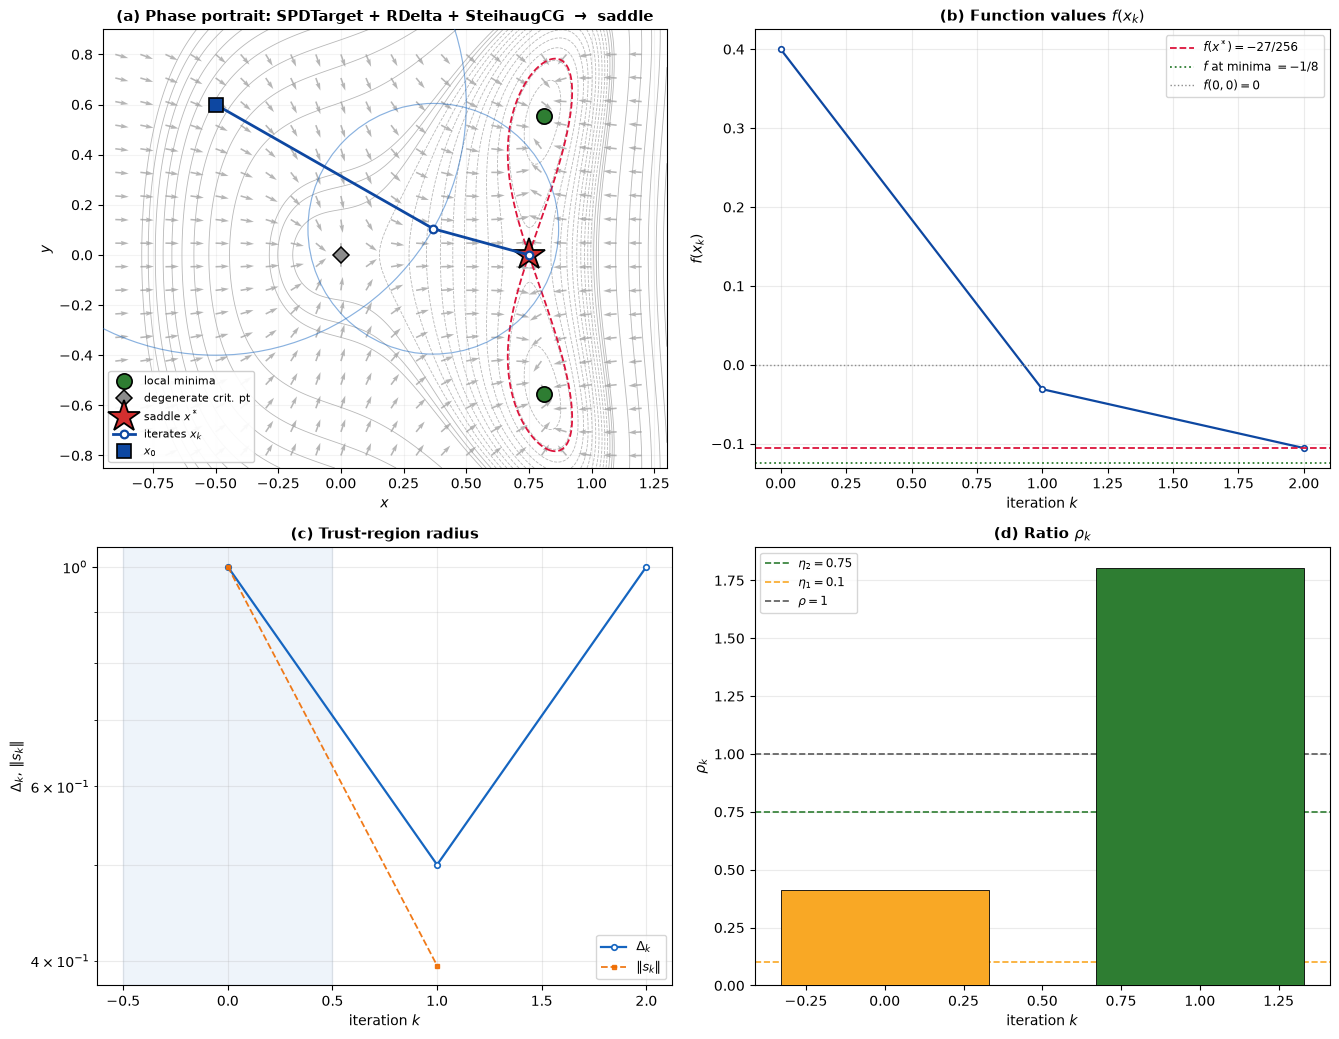

In [20]:
# Writes diag_spd_saddle.pdf, the name Part III compiles against.
#
# It used to write diagnose_Rdelta_SPD.png: a different name and a different
# format, so the figure in the manuscript was produced only by the shadow
# notebook. Retiring the shadow would have left that figure with no producer.
# The manuscript is unchanged; this notebook now produces what it asks for.
# Three configurations with genuinely different limits.
diagnose(rule = mk_delta(), model = SPDTarget(target = SADDLE), subsolver = SteihaugCG(), 
            savepath = "diag_spd_saddle.pdf")

SR1Model + RGradCapped + SteihaugCG : first_order in 19 iters -> min+


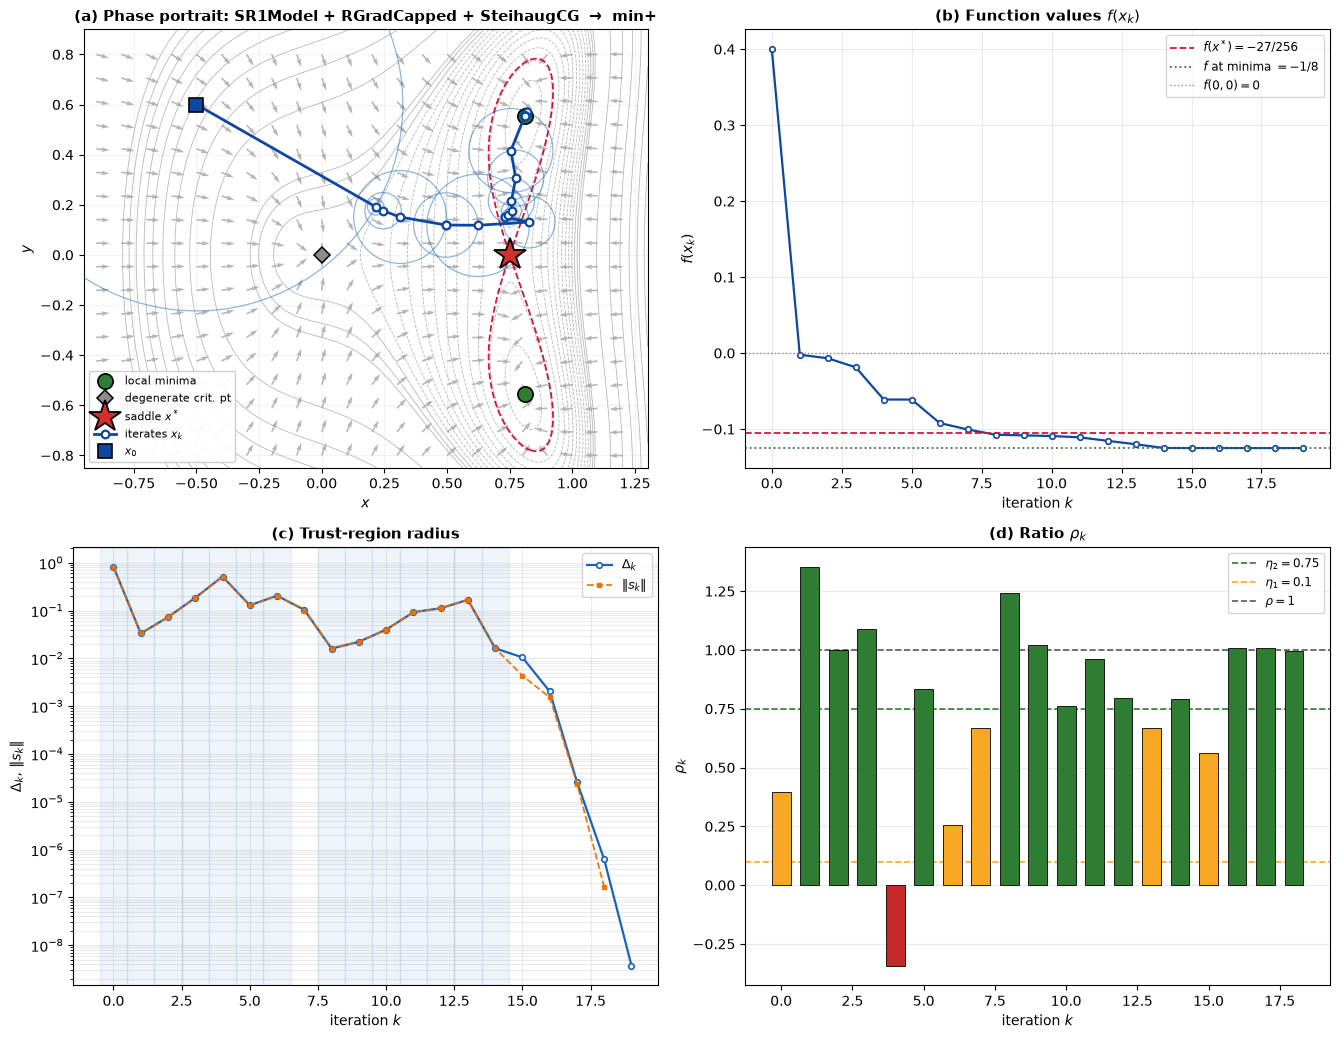

In [21]:
diagnose(rule = mk_gradcapped(), model = SR1Model(mem = 10), subsolver = SteihaugCG(), 
            savepath = "RGradCapped-SR1.png")

ExactHessian + SecondOrder + EigenPoint : second_order in 13 iters -> min-


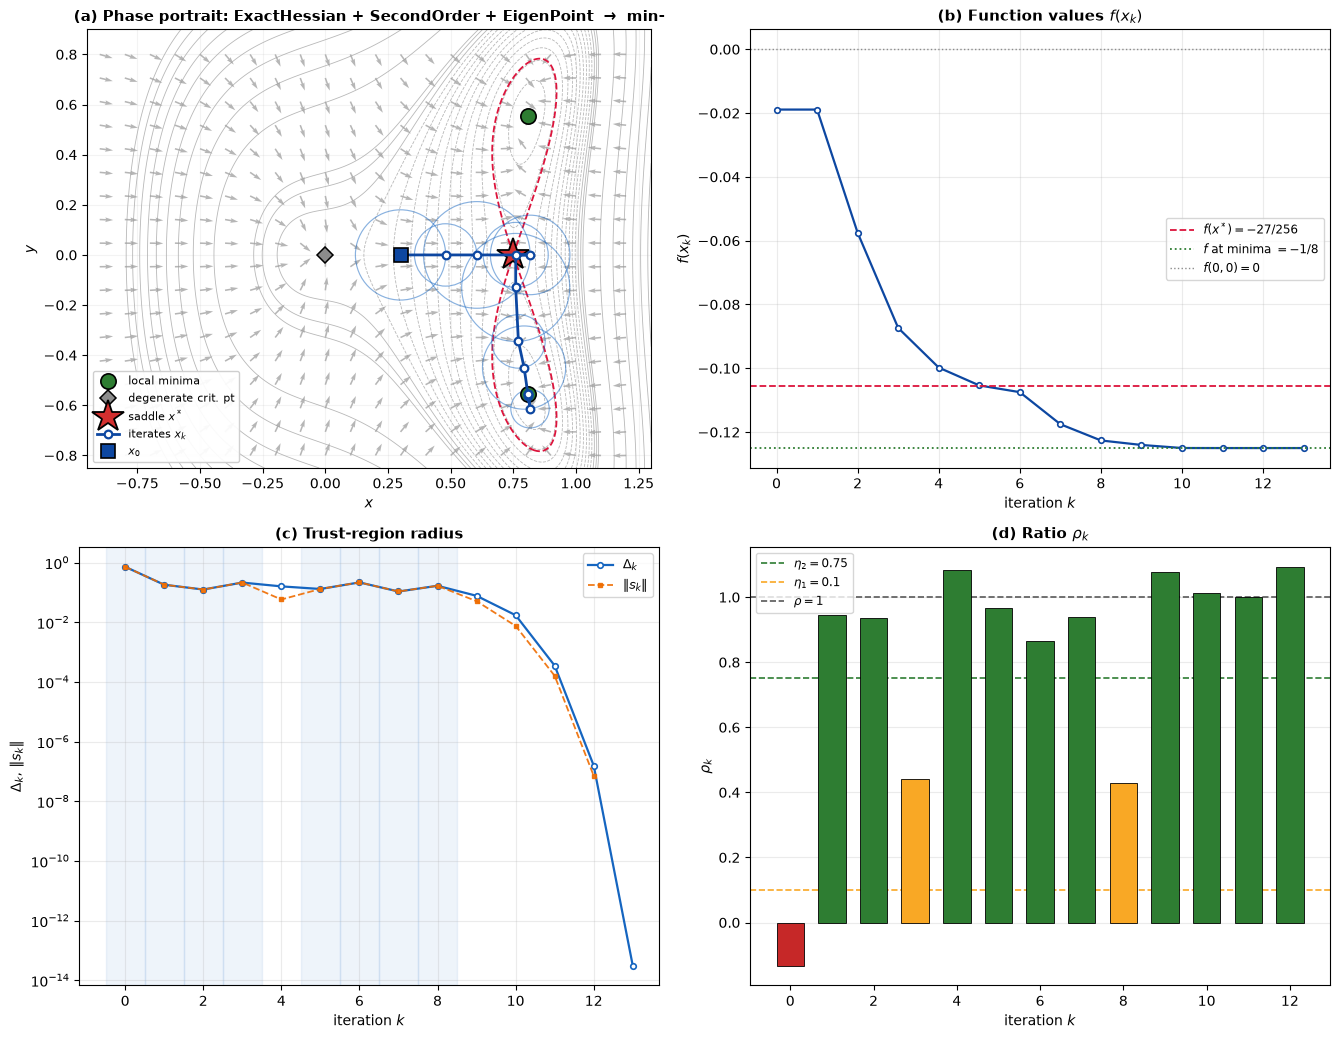

In [22]:
# Second-order anchoring at the non-degenerate saddle: τ keeps Δ alive, EigenPoint escapes.
diagnose(rule = RGradTau(μ = 1.0), model = ExactHessian(),
         subsolver = EigenPoint(SteihaugCG()),
         x0 = X0_TO_SADDLE, tol_H = TOL_H, kmax = 5_000, 
         savepath = "RGradTau_EigenPoint.png")

ExactHessian + RGradCapped + SteihaugCG : first_order in 57670 iters -> origin


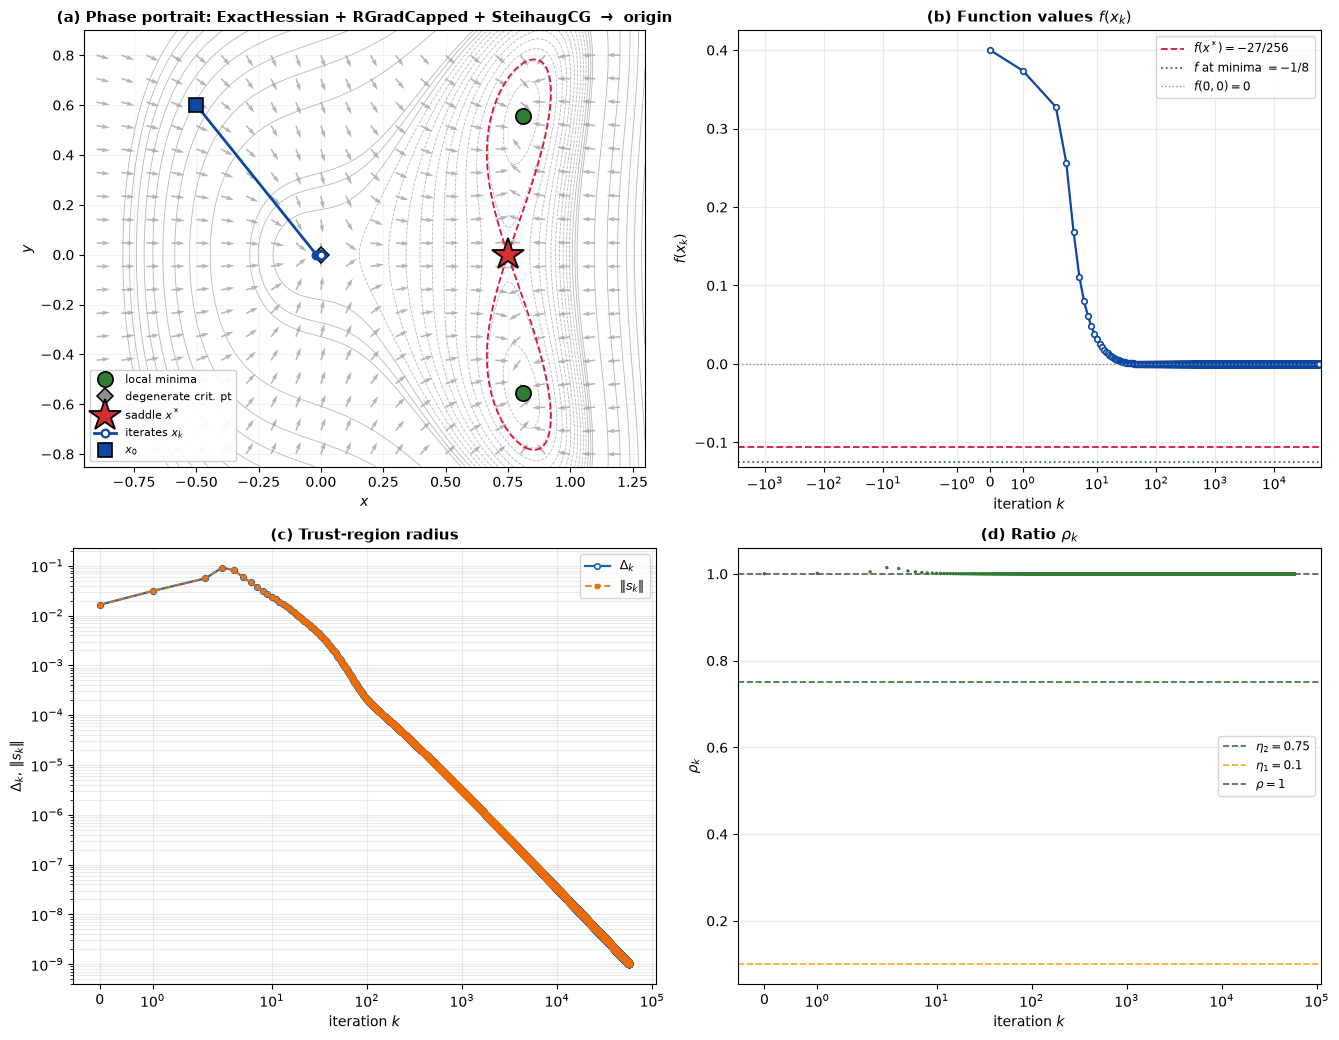

In [23]:
diagnose(rule = RGradCapped(μ = 0.01, μ_max=0.1), model = ExactHessian(),
         subsolver = SteihaugCG(),
         kmax = 60000, 
         savepath = "RGradCapped_Steihaug.png")

ExactHessian + RGradCapped + SteihaugCG : stalled in 4021 iters -> min+


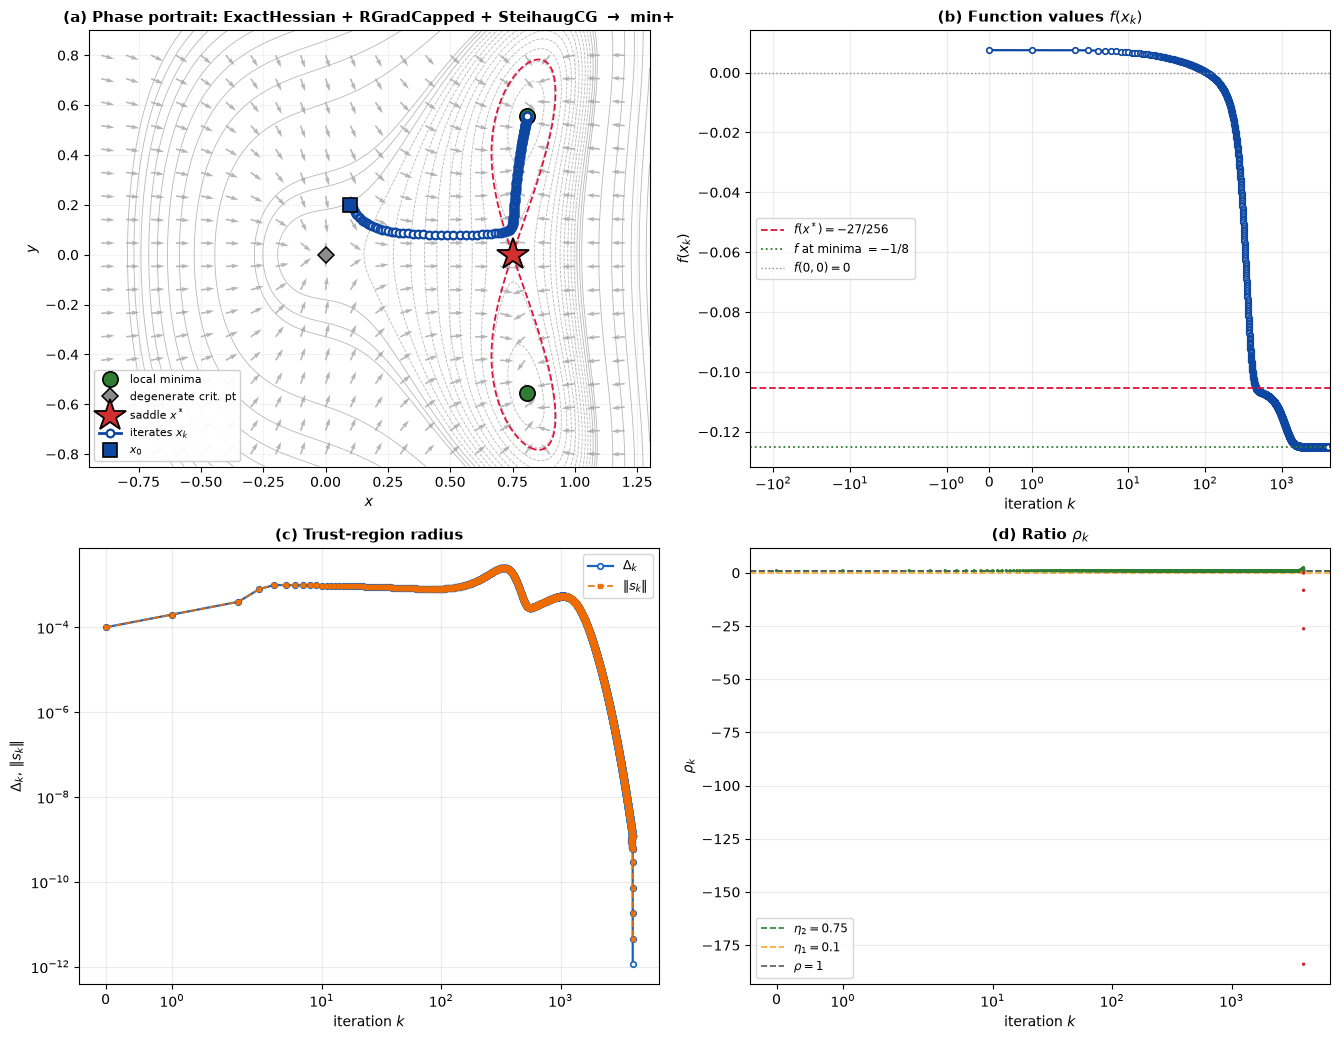

In [24]:
diagnose(rule = RGradCapped(μ = 0.001, μ_max=0.01), model = ExactHessian(),
         subsolver = SteihaugCG(),
         x0 = [0.1, 0.2], 
         kmax = 60000, 
         savepath = "RGradCapped_Steihaug.png")

### Figure 1 — phase portrait with iterate trajectories

Rendered with **PyPlot.jl** (matplotlib) for publication-quality output. Level sets in grey, the
normalised negative-gradient field as a quiver, and the four critical points marked. Trust-region
circles are deliberately omitted: with several trajectories overlaid they obscure the level sets,
and the point of this figure is *where the runs go*, not how large the region was at each step.

The three trajectories are chosen to be the ones with genuinely different limits — the same
starting point delivered to three different critical points by three different model Hessians.

One detail is worth watching. The true-Hessian and SPD runs are **identical for $k = 0,\dots,3$**:
the initial radius is small enough that CG truncates at the Cauchy point, so the step is along
$-g_k$ and the model Hessian has no influence on the direction at all. They separate only at
$k=4$, once the radius has grown enough for CG to take a second iteration. The curves are drawn
widest-first so the coincident opening segment stays visible for all of them.


In [34]:
"""
    plot_phase(runs; savepath, x0, xlims, ylims)

Phase portrait with level sets, the normalised negative-gradient field, the four critical
points, and one polyline per run.

`runs` is a vector of `(label, st, xs, colour, marker)`, where `st` is the stats object from
`tr_solve` and `xs` the iterate path from its callback — i.e. exactly what `solve_path`
returns. No trust-region circles: they obscure the level sets when several runs are overlaid.
"""
function plot_phase(runs; savepath = nothing, x0 = X0_DEFAULT,
                    xlims = (-0.85, 1.30), ylims = (-0.85, 0.90))
    fig = PyPlot.figure(figsize = (8.6, 6.4))
    ax  = fig.add_subplot(1, 1, 1)

    # ---------- level sets ----------
    xg = range(xlims[1], xlims[2], length = 420)
    yg = range(ylims[1], ylims[2], length = 380)
    Xg = [xi for yi in yg, xi in xg]
    Yg = [yi for yi in yg, xi in xg]
    Zg = @. Xg^4 - Xg^3 + (0.25 - Xg/2)*Yg^2 + Yg^4/4
    lv = sort(vcat(collect(range(-0.13, 0.02, length = 14)),
                   collect(range(0.03, 0.9, length = 10))))
    ax.contour(Xg, Yg, Zg, levels = lv, colors = "0.72", linewidths = 0.6, zorder = 1)
    ax.contour(Xg, Yg, Zg, levels = [f(SADDLE)], colors = "crimson",
               linewidths = 1.3, linestyles = "--", zorder = 2)

    # ---------- normalised -grad field ----------
    xq = range(xlims[1]+0.05, xlims[2]-0.05, length = 22)
    yq = range(ylims[1]+0.05, ylims[2]-0.05, length = 18)
    QX = Float64[]; QY = Float64[]; QU = Float64[]; QV = Float64[]
    for xi in xq, yi in yq
        gg = -grad([xi, yi]); n = norm(gg)
        n == 0 && continue
        push!(QX, xi); push!(QY, yi); push!(QU, gg[1]/n); push!(QV, gg[2]/n)
    end
    ax.quiver(QX, QY, QU, QV, color = "0.62", width = 0.0028, scale = 42,
              alpha = 0.75, zorder = 1)

    # ---------- critical points ----------
    ax.plot([MINP[1], MINM[1]], [MINP[2], MINM[2]], "o", ms = 10, mfc = "#2e7d32",
            mec = "k", mew = 1.2, zorder = 6, label = "local minima")
    ax.plot([ORIGIN[1]], [ORIGIN[2]], "D", ms = 8, mfc = "0.55", mec = "k", mew = 1.1,
            zorder = 6, label = "degenerate crit. pt")
    ax.plot([SADDLE[1]], [SADDLE[2]], "*", ms = 22, mfc = "#d32f2f", mec = "k", mew = 1.3,
            zorder = 7, label = "saddle \$x^*\$")

    # ---------- trajectories ----------
    # Draw widest-first: several runs share their opening iterations exactly (the radius
    # is small enough that CG truncates at the Cauchy point, so the model is irrelevant
    # until it grows). Tapering the width lets every coincident curve stay visible.
    for (j, (lab, st, xs, col, mk)) in enumerate(runs)
        P  = reduce(hcat, xs)
        lw = 4.2 - 1.1*(j-1)
        ms = 8.0 - 1.6*(j-1)
        ax.plot(P[1, :], P[2, :], "-"*mk, color = col, ms = ms, lw = lw, mfc = "white",
                mec = col, mew = 1.3, alpha = 0.95, zorder = 7+j, label = lab)
        if st.status === :exception            # no model exists at this iterate
            ax.plot([P[1, end]], [P[2, end]], "X", ms = 13, mfc = "#c62828", mec = "k",
                    mew = 1.3, zorder = 10)
        end
    end
    ax.plot([x0[1]], [x0[2]], "s", ms = 10, mfc = "k", mec = "k", mew = 1.2,
            zorder = 9, label = "\$x_0\$")

    ax.set_xlabel("\$x\$"); ax.set_ylabel("\$y\$")
    ax.legend(loc = "lower left", fontsize = 8, framealpha = 0.93)
    ax.set_xlim(xlims...); ax.set_ylim(ylims...)
    ax.set_aspect("equal"); ax.grid(alpha = 0.14)

    PyPlot.tight_layout()
    savepath === nothing || PyPlot.savefig(savepath, bbox_inches = "tight")
    return fig
end

plot_phase

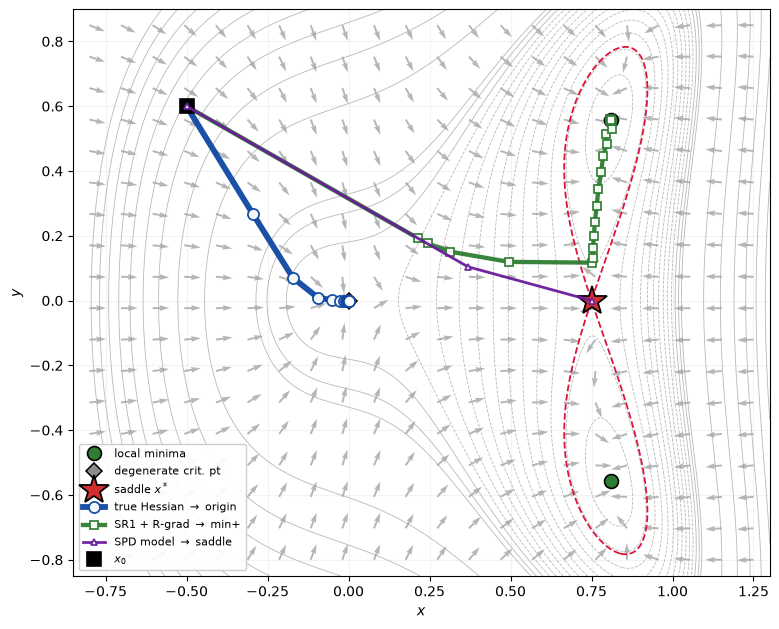

true Hessian   first_order      14 iters → origin
SR1 + R-grad   first_order      21 iters → min+
SPD→saddle     first_order       2 iters → saddle
✓ wrote fig1_phase_portrait.pdf


In [35]:
# ---- the three runs with genuinely different limits ----
x0_run = [-0.5, 0.6]

st_true, xs_true = solve_path(rule = mk_delta(), model = ExactHessian(),
                              subsolver = SteihaugCG(), x0 = x0_run, kmax = 4000, tol = 1e-8)
st_qn,   xs_qn   = solve_path(rule = RGradCapped(γ1 = G1, γ2 = G2, γ3 = G3,
                                                 μ = MU0, μ_max = 1.0),
                              model = SR1Model(mem = 10),
                              subsolver = SteihaugCG(), x0 = x0_run, kmax = 4000, tol = 1e-8)
st_spd,  xs_spd  = solve_path(rule = mk_delta(), model = SPDTarget(target = SADDLE),
                              subsolver = SteihaugCG(), x0 = x0_run, kmax = 4000, tol = 1e-8)

for (lab, st) in (("true Hessian", st_true), ("SR1 + R-grad", st_qn), ("SPD→saddle", st_spd))
    @printf("%-14s %-13s %5d iters → %s\n", lab, string(st.status), st.iter,
            which_crit(st.solution))
end

fig1 = plot_phase([("true Hessian \$\\to\$ " * which_crit(st_true.solution),
                    st_true, xs_true, "#0d47a1", "o"),
                   ("SR1 + R-grad \$\\to\$ " * which_crit(st_qn.solution),
                    st_qn,   xs_qn,   "#2e7d32", "s"),
                   ("SPD model \$\\to\$ "    * which_crit(st_spd.solution),
                    st_spd,  xs_spd,  "#6a1b9a", "^")];
                    x0 = x0_run,
                  savepath = "fig1_phase_portrait.pdf")
display(fig1)
println("✓ wrote fig1_phase_portrait.pdf")

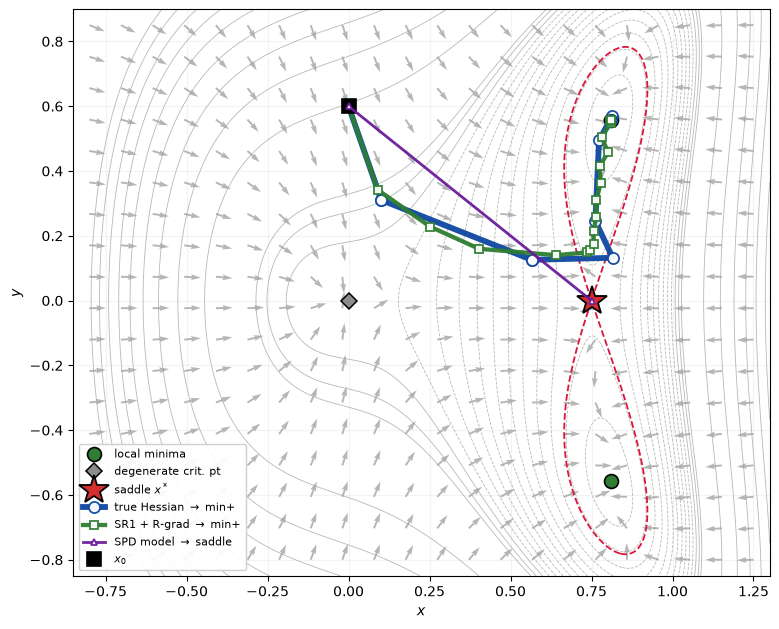

true Hessian   first_order      11 iters → min+
SR1 + R-grad   first_order      20 iters → min+
SPD→saddle     first_order       1 iters → saddle
✓ wrote fig2_phase_portrait.pdf


In [36]:
# ---- the three runs with genuinely different limits ----
x0_run = [0.0, 0.6]

st_true, xs_true = solve_path(rule = mk_delta(), model = ExactHessian(),
                              subsolver = SteihaugCG(), x0 = x0_run, kmax = 4000, tol = 1e-8)
st_qn,   xs_qn   = solve_path(rule = RGradCapped(γ1 = G1, γ2 = G2, γ3 = G3,
                                                 μ = MU0, μ_max = 1.0),
                              model = SR1Model(mem = 10),
                              subsolver = SteihaugCG(), x0 = x0_run, kmax = 4000, tol = 1e-8)
st_spd,  xs_spd  = solve_path(rule = mk_delta(), model = SPDTarget(target = SADDLE),
                              subsolver = SteihaugCG(), x0 = x0_run, kmax = 4000, tol = 1e-8)

for (lab, st) in (("true Hessian", st_true), ("SR1 + R-grad", st_qn), ("SPD→saddle", st_spd))
    @printf("%-14s %-13s %5d iters → %s\n", lab, string(st.status), st.iter,
            which_crit(st.solution))
end

fig2 = plot_phase([("true Hessian \$\\to\$ " * which_crit(st_true.solution),
                    st_true, xs_true, "#0d47a1", "o"),
                   ("SR1 + R-grad \$\\to\$ " * which_crit(st_qn.solution),
                    st_qn,   xs_qn,   "#2e7d32", "s"),
                   ("SPD model \$\\to\$ "    * which_crit(st_spd.solution),
                    st_spd,  xs_spd,  "#6a1b9a", "^")];
                    x0 = x0_run,
                  savepath = "fig2_phase_portrait.pdf")
display(fig2)
println("✓ wrote fig2_phase_portrait.pdf")

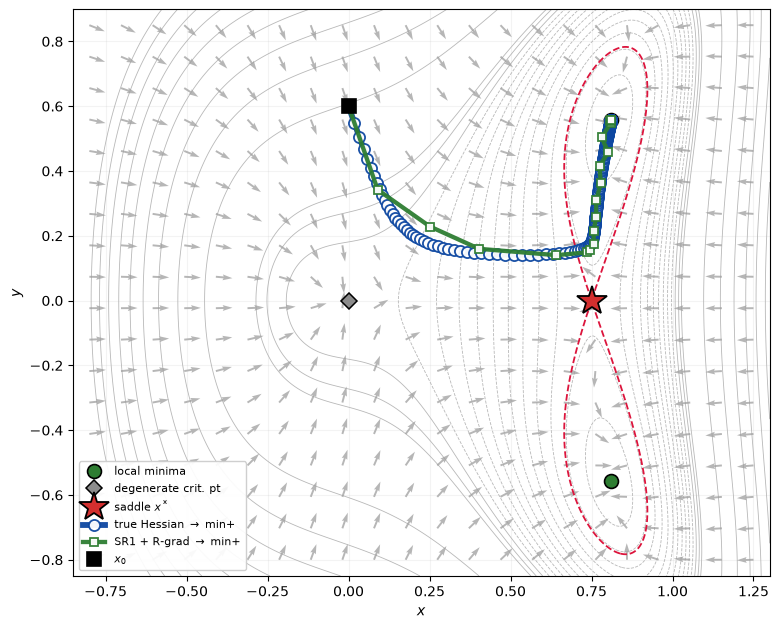

✓ wrote pdf


In [37]:


# ---- the three runs with genuinely different limits ----
x0_run = [0.0, 0.6]

st_true, xs_true = solve_path(rule = RGradCapped(μ = 0.1, μ_max=0.1), model = ExactHessian(),
                              subsolver = SteihaugCG(), x0 = x0_run, kmax = 4000, tol = 1e-8)
st_qn,   xs_qn   = solve_path(rule = RGradCapped(μ = MU0, μ_max = 1.0),
                              model = SR1Model(mem = 10),
                              subsolver = SteihaugCG(), x0 = x0_run, kmax = 4000, tol = 1e-8)


fig3 = plot_phase([("true Hessian \$\\to\$ " * which_crit(st_true.solution),
                    st_true, xs_true, "#0d47a1", "o"),
                   ("SR1 + R-grad \$\\to\$ " * which_crit(st_qn.solution),
                    st_qn,   xs_qn,   "#2e7d32", "s")];
                    x0 = x0_run,
                  savepath = "fig3_phase_portrait.pdf")
display(fig3)
println("✓ wrote pdf")

## Porting the remainder onto the package

From here the notebook was written against the hand-coded driver and never ported: fifteen cells raised `UndefVarError` or a `MethodError`. The next cell defines the shadow API in terms of `tr_solve`, `run_cfg`, `solve_path` and `which_crit`, so the analysis below runs on the package rather than on a second implementation of it.

One entry in that mapping is not a rename. The shadow's `RGrad(μmax = m)` grows μ unconditionally, while the package's `RGradCapped` grows it only when the step exceeds half the radius, so the faithful translation is `RGradCapped(μ_max = m, half_test = false)`. Which of the two the sweeps should use is a real choice and is made explicitly in the next cell.

In [38]:
# =====================================================================
# The shadow API, re-expressed on the package
# =====================================================================
#
# Everything from here to the end of the notebook was written against the
# hand-coded driver in `_shadow/saddle_discussion.ipynb` and never ported. The
# names it wants (`Row`, `run_tr`, `classify`, `TrueHessian`, `LBFGS`, `SR1`,
# `steihaug`) do not exist in the package, so fifteen cells raised.
#
# They are defined here, once, in terms of the idioms the first half of this
# notebook already uses (`run_cfg`, `solve_path`, `which_crit`), rather than by
# rewriting fifteen cells. Nothing below reimplements an iteration: every run
# goes through `tr_solve`, and every step through the package's own CG.
#
# The mapping, and the one place it is not a rename:
#
#   TrueHessian()      -> ExactHessian()
#   LBFGS(m = 5)       -> LBFGSModel(mem = 5)
#   SR1()              -> SR1Model(mem = 10)
#   steihaug(g, B, Δ)  -> SteihaugCG() through solve_subproblem!
#   run_tr(...)        -> solve_path, and stats.solver_specific
#   rows[k].x          -> the path from the callback
#
#   RGrad(μmax = m)    -> RGradCapped(μ = min(MU0, m), μ_max = m)
#
# The last is not a rename and the shadow notebook's own comparison table got it
# wrong. The shadow's update is
#
#     else
#         r.μ = min(r.γ3*r.μ, r.μmax)     # unconditional
#
# whereas RGradCapped grows μ only when ‖s_k‖ > ½Δ_k. So the exact
# correspondence is RGradCapped(μ_max = m, half_test = false).
#
# HALF_TEST below chooses which rule the ported sweeps run. It is `true`, the
# package default and the rule the survey analyses: the half-step guard is what
# turns "μ grows" into "‖s_k‖ is comparable to μ_k‖g_k‖", which is the step the
# boundedness argument for μ runs on, so a sweep that drops it is measuring a
# different rule from the one Part II proves things about. Set it to `false` to
# reproduce the published figures instead. The cell after the μ sweep runs both
# and reports whether the limit points differ.
const HALF_TEST = true

TrueHessian() = ExactHessian()
LBFGS(; m::Int = 5)  = LBFGSModel(mem = m)
LBFGS(m::Int)        = LBFGSModel(mem = m)
SR1(; mem::Int = 10) = SR1Model(mem = mem)

"R-grad with a cap, in the package's spelling. See HALF_TEST above."
rgrad_capped(μmax; half_test = HALF_TEST) =
    RGradCapped(γ1 = G1, γ2 = G2, γ3 = G3,
                μ = min(MU0, μmax), μ_max = μmax, half_test = half_test)

"""
    Row

One iteration of a run, in the shape the plotting code downstream expects:
`k`, the iterate `x`, the radius `Δ`, `‖g‖`, the ratio `ρ`, and whether the
constraint was active and the step accepted.
"""
struct Row
    k::Int
    x::Vector{Float64}
    Δ::Float64
    g::Float64
    ρ::Float64
    active::Bool
    accepted::Bool
end

"""
    run_tr(x0; radius, model, solver, kmax, tol) -> (rows, status, xfinal)

The shadow driver's signature, backed by `tr_solve`. `solver` is `:cg` for
Steihaug-Toint truncated CG and `:ms` for exact Moré-Sorensen.

`rows[j].x` is the iterate the callback recorded, so `rows` carries the iterate
path the phase portraits need and which the trace alone does not hold.
"""
function run_tr(x0; radius, model = ExactHessian(), solver::Symbol = :cg,
                kmax::Int = KMAX, tol::Real = TOL, Δ0 = DELTA0, η = ETA1)
    sub = solver === :cg ? SteihaugCG() :
          solver === :ms ? ExactMS() :
          throw(ArgumentError("run_tr: solver must be :cg or :ms, got :$solver"))
    st, xs = solve_path(x0 = x0, rule = radius, model = model, subsolver = sub,
                        kmax = kmax, tol = tol, Δ0 = Δ0, η = η)
    ss = st.solver_specific
    Δ  = ss[:delta_trajectory]; g = ss[:grad_trajectory]
    ρ  = ss[:ratio_trajectory]; a = ss[:active_trajectory]
    ac = ss[:accepted_trajectory]
    # A stalled run records one fewer state entry than a completed one, so take
    # the length every series actually has rather than assuming k+1.
    n = min(length(xs), length(Δ), length(g))
    rows = [Row(j - 1, xs[j], Δ[j], g[j],
                j <= length(ρ)  ? ρ[j]  : NaN,
                j <= length(a)  ? a[j]  : false,
                j <= length(ac) ? ac[j] : false) for j in 1:n]
    return rows, string(st.status), copy(st.solution)
end

"Classify a limit point. The shadow's `classify(x, status; tol)` argument order."
classify(x, status = ""; tol = 1e-4) = which_crit(x; tol = tol)

"""
    steihaug(g, B, Δ) -> (s, active, iters)

The shadow's raw subproblem call, routed through the package's `SteihaugCG`
rather than through a second copy of the recurrence. `B` is a plain matrix, so
it is wrapped in the quadratic whose gradient at the origin is `g` and whose
Hessian is `B`; `ExactHessian` then hands CG exactly `B`.
"""
function steihaug(g::AbstractVector, B::AbstractMatrix, Δ::Real)
    n = length(g)
    Bs = Symmetric(Matrix(B))
    nlp = ADNLPModel(z -> 0.5 * dot(z, Bs * z) + dot(g, z), zeros(n))
    mdl = ExactHessian(); reset_model!(mdl, n)
    x  = zeros(n); gv = collect(float.(g))
    s  = zeros(n); Hs = zeros(n); ws = SubWorkspace(zeros(n))
    active = solve_subproblem!(SteihaugCG(), mdl, nlp, x, gv, float(Δ), s, Hs, ws)
    return s, active, ws.iters
end

println("✓ shadow API bridged onto the package")
println("  R-grad cap runs with half_test = ", HALF_TEST,
        HALF_TEST ? " (the rule the survey analyses)" : " (the shadow's rule)")

# --- names the tail uses that were never defined anywhere in this notebook ---
#
# `escape_k` and `X0_FIG` live in the shadow notebook and were not carried across
# with the rest. They are not part of the shadow API; they are ordinary values
# the tail happens to need.

"First iteration on which the trajectory has left the band |y| <= 0.5."
function escape_k(h)
    i = findfirst(x -> abs(x[2]) > 0.5, h.xs)
    return i === nothing ? nothing : h.ks[i]
end

const X0_FIG = [-0.5, 0.6]

"""
    run_tr_full(x0; ...) -> (rows, status, xfinal, stats, xs)

`run_tr` plus the two objects `plot_phase` wants. `plot_phase` takes tuples of
`(label, stats, xs, colour, marker)`, and the sweeps below were written to push
`(label, rows, colour, marker)`, four elements against five, which is why they
raised `BoundsError ... at index [5]` once they finally ran.
"""
function run_tr_full(x0; radius, model = ExactHessian(), solver::Symbol = :cg,
                     kmax::Int = KMAX, tol::Real = TOL, Δ0 = DELTA0, η = ETA1)
    sub = solver === :cg ? SteihaugCG() : ExactMS()
    st, xs = solve_path(x0 = x0, rule = radius, model = model, subsolver = sub,
                        kmax = kmax, tol = tol, Δ0 = Δ0, η = η)
    ss = st.solver_specific
    Δ  = ss[:delta_trajectory]; g = ss[:grad_trajectory]
    ρ  = ss[:ratio_trajectory]; a = ss[:active_trajectory]; ac = ss[:accepted_trajectory]
    n  = min(length(xs), length(Δ), length(g))
    rows = [Row(j - 1, xs[j], Δ[j], g[j],
                j <= length(ρ)  ? ρ[j]  : NaN,
                j <= length(a)  ? a[j]  : false,
                j <= length(ac) ? ac[j] : false) for j in 1:n]
    return rows, string(st.status), copy(st.solution), st, xs
end

const PhaseRun = Tuple{String, Any, Vector{Vector{Float64}}, String, String}

"Title for the slow-saddle flow figures, which used an undefined `ttl`."
slow_title(ε) = "Gradient flow and the escaping trajectory,  ε = " * string(ε)

# `sci` is used by the slow-saddle table below and is defined nowhere in this
# notebook, so the call resolved to `PyPlot.sci` (matplotlib's "set current
# image"), which has no `d` keyword: a TypeError rather than an UndefVarError,
# which is why it read as a plotting fault rather than a missing helper. This is
# the same formatter the other notebooks carry.
"Format `x` in LaTeX scientific notation with `d` significant decimals."
function sci(x; d = 3)
    isinf(x) && return "\$" * (x > 0 ? "+" : "-") * "\\infty\$"
    isnan(x) && return "---"
    x == 0   && return "\$0\$"
    e = floor(Int, log10(abs(x)))
    m = x / 10.0^e
    return @sprintf("\$%.*f\\times10^{%d}\$", d, m, e)
end

# `latex_table` is used by the table cell below and defined nowhere in this
# notebook. Same helper the TR_mechanisms notebook carries.
"""
    latex_table(io, header, rows; caption, label, align, note)

Write a `booktabs` table to `io`.  `rows` is a vector of vectors of already-formatted
strings.  Pass `stdout` to preview, or use `open(io -> latex_table(io, ...), path, "w")`
to write a standalone file for `input`.
"""
function latex_table(io::IO, header, rows; caption = "", label = "", align = "", note = "")
    align = isempty(align) ? "l" * "r"^(length(header) - 1) : align
    println(io, "\\begin{table}[htbp]")
    println(io, "  \\centering")
    isempty(caption) || println(io, "  \\caption{", caption, "}")
    isempty(label)   || println(io, "  \\label{", label, "}")
    println(io, "  \\begin{tabular}{", align, "}")
    println(io, "    \\toprule")
    println(io, "    ", join(header, " & "), " \\\\")
    println(io, "    \\midrule")
    for r in rows
        println(io, "    ", join(r, " & "), " \\\\")
    end
    println(io, "    \\bottomrule")
    println(io, "  \\end{tabular}")
    isempty(note) || println(io, "  \\\\[2pt] \\footnotesize ", note)
    println(io, "\\end{table}")
    return nothing
end


✓ shadow API bridged onto the package
  R-grad cap runs with half_test = true (the rule the survey analyses)


latex_table

In [39]:
# ---- R-DFO with the true Hessian, across the ζ sweep ----
X0_ZFIG    = [-0.1, 0.6]
ZETA_SWEEP = [0.001, 0.1, 0.5, 1.0, 2.0, 10.0, 100.0]
KMAX_ZFIG  = 4000

ZCOLS = ["#0d47a1", "#1565c0", "#00838f", "#2e7d32",
         "#ef6c00", "#c62828", "#6a1b9a"]
ZMKS  = ["o", "s", "^", "v", "D", "P", "*"]

zeta_runs = PhaseRun[]
for (j, ζ) in enumerate(ZETA_SWEEP)
    rws, st, xf, stats, xs = run_tr_full(X0_ZFIG; radius=RDFO(ζ=ζ), model=TrueHessian(),
                         solver=:cg, kmax=KMAX_ZFIG, tol=1e-8)
    lab = "\$\\zeta = " * (ζ < 0.01 ? @sprintf("%.3f", ζ) : @sprintf("%g", ζ)) * "\$"
    push!(zeta_runs, (lab, stats, xs, ZCOLS[j], ZMKS[j]))
    @printf("ζ = %8.3f : %-11s k = %5d, limit = %-10s |x_final| = %.3e\n",
            ζ, st, rws[end].k, classify(xf, st; tol=1e-3), norm(xf))
end

ζ =    0.001 : max_iter    k =  4000, limit = other      |x_final| = 7.503e-01
ζ =    0.100 : stalled     k =   450, limit = min-       |x_final| = 9.816e-01
ζ =    0.500 : first_order k =    47, limit = min-       |x_final| = 9.816e-01
ζ =    1.000 : first_order k =    20, limit = min-       |x_final| = 9.816e-01
ζ =    2.000 : first_order k =    16, limit = min-       |x_final| = 9.816e-01
ζ =   10.000 : first_order k =    11, limit = min-       |x_final| = 9.816e-01
ζ =  100.000 : first_order k =    13, limit = min-       |x_final| = 9.816e-01


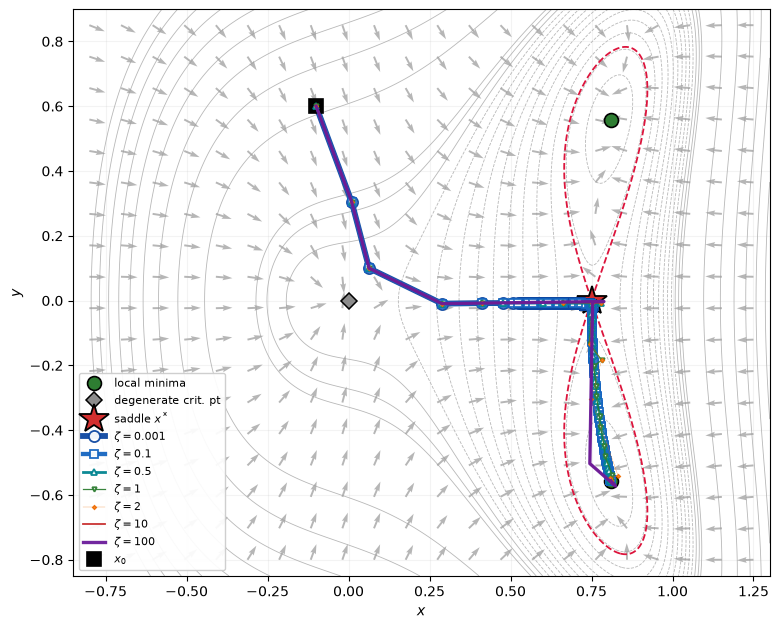

✓ wrote fig4_rdfo_zeta_phase.pdf


In [40]:
fig_z = plot_phase(zeta_runs; x0 = X0_ZFIG,
                   savepath = "fig4_rdfo_zeta_phase.pdf")
display(fig_z)
println("✓ wrote fig4_rdfo_zeta_phase.pdf")

In [41]:
# ---- R-grad with the true Hessian, across the μmax sweep ----
X0_MFIG   = [-0.5, 0.6]
MU_SWEEP  = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 4.0, 8.0, 128.0]
KMAX_MFIG = 4000

MCOLS = ["#0d47a1", "#1565c0", "#0288d1", "#00838f", "#2e7d32",
         "#9e9d24", "#ef6c00", "#d84315", "#c62828", "#6a1b9a"]
MMKS  = ["o", "s", "^", "v", "D", "P", "*", "X", "<", ">"]

"Run the μmax sweep for one model, printing a summary and returning plot tuples."
function mu_sweep(modelf; x0=X0_MFIG, μs=MU_SWEEP, kmax=KMAX_MFIG, label="")
    runs = PhaseRun[]
    seen = Matrix{Float64}[]
    println("R-grad μmax sweep — ", label, ", from ", x0, "\n")
    @printf("%9s %7s %-11s %-11s %10s\n", "μmax", "iters", "status", "limit", "λmin(∇²f)")
    println("-"^54)
    for (j, μ) in enumerate(μs)
        rws, st, xf, stats, xs = run_tr_full(x0; radius=rgrad_capped(μ), model=modelf(),
                             solver=:cg, kmax=kmax, tol=1e-8)
        P = hcat([r.x for r in rws]...)
        dup = findfirst(Q -> size(Q) == size(P) && Q == P, seen)
        push!(seen, P)
        λH = eigvals(Symmetric(hess(xf)))[1]
        @printf("%9.2f %7d %-11s %-11s %10.4f%s\n",
                μ, rws[end].k, st, classify(xf, st; tol=1e-3), λH,
                dup === nothing ? "" : @sprintf("  [= μmax %g]", μs[dup]))
        dup === nothing || continue
        push!(runs, ("\$\\mu_{\\max} = " * @sprintf("%g", μ) * "\$",
                     stats, xs, MCOLS[j], MMKS[j]))
    end
    return runs
end

mu_sweep

R-grad μmax sweep — true Hessian, from [-0.5, 0.6]

     μmax   iters status      limit        λmin(∇²f)
------------------------------------------------------
     0.01    4000 max_iter    other           0.0464
     0.05    4000 max_iter    other           0.0098
     0.10    4000 max_iter    origin          0.0049
     0.30    4000 max_iter    origin          0.0017
     0.50    4000 max_iter    origin          0.0010
     1.00    4000 max_iter    origin          0.0005
     2.00    2880 first_order origin          0.0003
     4.00    1705 first_order origin          0.0003
     8.00     530 first_order origin          0.0003
   128.00      33 first_order origin          0.0003

✓ wrote fig6_rgrad_mu_true_phase.pdf


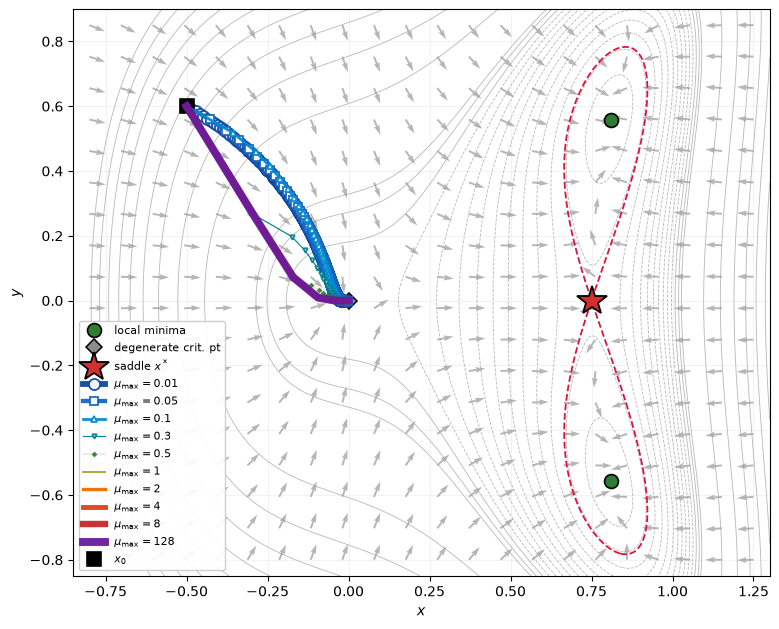

In [42]:
runs_mu_true = mu_sweep(() -> TrueHessian(); label = "true Hessian")

fig_mu_true = plot_phase(runs_mu_true; x0 = X0_MFIG,
                         savepath = "fig6_rgrad_mu_true_phase.pdf")
display(fig_mu_true)
println("\n✓ wrote fig6_rgrad_mu_true_phase.pdf")

R-grad μmax sweep — L-BFGS(m=5), from [-0.5, 0.6]

     μmax   iters status      limit        λmin(∇²f)
------------------------------------------------------
     0.01    4000 max_iter    other           0.0464
     0.05    4000 max_iter    other           0.0098
     0.10    4000 max_iter    origin          0.0049
     0.30    4000 max_iter    origin          0.0016
     0.50      84 stalled     min+            0.4947
     1.00      30 first_order min+            0.4947
     2.00      20 first_order min+            0.4947
     4.00      21 first_order min+            0.4947
     8.00      21 first_order min+            0.4947  [= μmax 4]
   128.00      21 first_order min+            0.4947  [= μmax 4]

✓ wrote fig8_rgrad_mu_lbfgs_phase.pdf


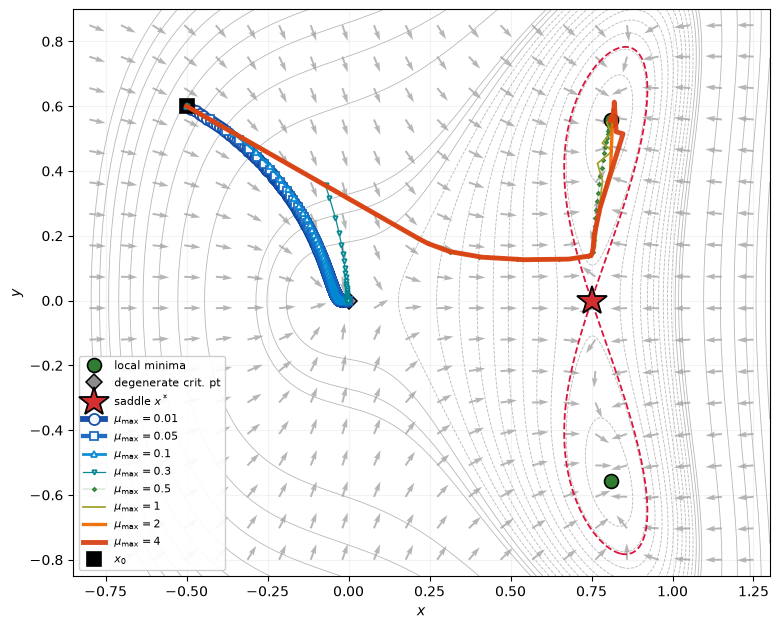

In [43]:
# ---- R-grad with L-BFGS, across the μmax sweep ----
runs_mu_lbfgs = mu_sweep(() -> LBFGS(m=5); label = "L-BFGS(m=5)")

fig_mu_lbfgs = plot_phase(runs_mu_lbfgs; x0 = X0_MFIG,
                          savepath = "fig8_rgrad_mu_lbfgs_phase.pdf")
display(fig_mu_lbfgs)
println("\n✓ wrote fig8_rgrad_mu_lbfgs_phase.pdf")

# Non-singular 


In [44]:
# ================================================================
# A nonsingular saddle with an arbitrarily long stall
# ================================================================
f_slow(p, ε)    = 0.5*p[1]^2 + ε*(p[2]^4/4 - p[2]^2/2)
grad_slow(p, ε) = [p[1], ε*p[2]*(p[2]^2 - 1)]
hess_slow(p, ε) = [1.0 0.0; 0.0 ε*(3p[2]^2 - 1)]

println("Critical points of f_ε(x,y) = ½x² + ε(¼y⁴ - ½y²)\n")
@printf("%-10s %-16s %-14s %-24s %s\n", "ε", "point", "f", "eig(∇²f)", "type")
println("-"^84)
for ε in [1e-1, 1e-2, 1e-3, 1e-4]
    for (nm, p) in [("(0,0)", [0.0,0.0]), ("(0,1)", [0.0,1.0])]
        w = eigvals(Symmetric(hess_slow(p, ε)))
        ty = w[1] < 0 ? "SADDLE (nonsingular)" : "minimiser"
        @printf("%-10.0e %-16s %-14.3e (%+.5f, %+.5f)   %s\n",
                ε, nm, f_slow(p, ε), w[1], w[2], ty)
    end
end
println("\ndet ∇²f(0,0) = -ε ≠ 0 : the saddle is NONSINGULAR for every ε > 0,")
println("and τ(0,0) = max{‖g‖, -λ⁻} = ε > 0 correctly flags it.")
println("The minimisers stay at distance 1 from the saddle as ε → 0.")

Critical points of f_ε(x,y) = ½x² + ε(¼y⁴ - ½y²)

ε          point            f              eig(∇²f)                 type
------------------------------------------------------------------------------------
1e-01      (0,0)            0.000e+00      (-0.10000, +1.00000)   SADDLE (nonsingular)
1e-01      (0,1)            -2.500e-02     (+0.20000, +1.00000)   minimiser
1e-02      (0,0)            0.000e+00      (-0.01000, +1.00000)   SADDLE (nonsingular)
1e-02      (0,1)            -2.500e-03     (+0.02000, +1.00000)   minimiser
1e-03      (0,0)            0.000e+00      (-0.00100, +1.00000)   SADDLE (nonsingular)
1e-03      (0,1)            -2.500e-04     (+0.00200, +1.00000)   minimiser
1e-04      (0,0)            0.000e+00      (-0.00010, +1.00000)   SADDLE (nonsingular)
1e-04      (0,1)            -2.500e-05     (+0.00020, +1.00000)   minimiser

det ∇²f(0,0) = -ε ≠ 0 : the saddle is NONSINGULAR for every ε > 0,
and τ(0,0) = max{‖g‖, -λ⁻} = ε > 0 correctly flags it.
The minimisers st

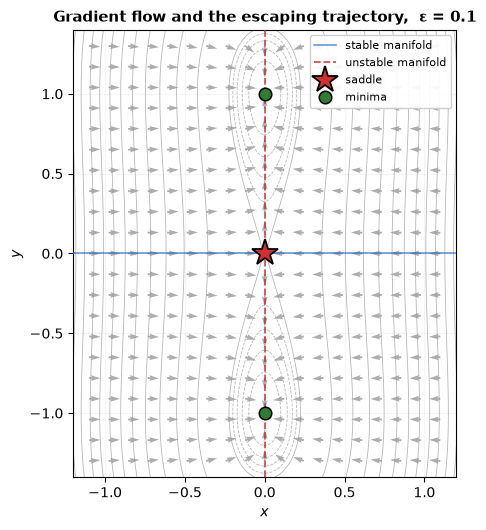

✓ wrote fig_slow_saddle_flow_eps1.pdf


In [45]:
# `ttl` and a bare `ε` were used here and defined nowhere: the title string and
# the loop variable both live in the shadow notebook and were not carried across.
# The cell already fixes the value it plots as `ε_PLOT`, so use that for both.
# Contour + gradient flow for ONE ε, with the escaping trajectory overlaid
ε_PLOT   = 0.1          # <- change this to plot a different ε
Y0_PANEL = 1e-3

fig_flow = PyPlot.figure(figsize=(5.6, 5.4))
ax = fig_flow.add_subplot(1, 1, 1)

# ---- level sets ----
xg = range(-1.2, 1.2, length=320)
yg = range(-1.4, 1.4, length=340)
Xg = [xi for yi in yg, xi in xg]
Yg = [yi for yi in yg, xi in xg]
Zg = @. 0.5*Xg^2 + ε_PLOT*(Yg^4/4 - Yg^2/2)
lv = sort(vcat(collect(range(-ε_PLOT/4, 0.0, length=6))[1:end-1],
               collect(range(1e-4, 0.7, length=12))))
ax.contour(Xg, Yg, Zg, levels=lv, colors="0.72", linewidths=0.6, zorder=1)

# ---- normalised -grad field ----
xq = range(-1.1, 1.1, length=19)
yq = range(-1.3, 1.3, length=21)
QX = Float64[]; QY = Float64[]; QU = Float64[]; QV = Float64[]
for xi in xq, yi in yq
    gg = -grad_slow([xi, yi], ε_PLOT); n = norm(gg)
    n < 1e-14 && continue
    push!(QX, xi); push!(QY, yi); push!(QU, gg[1]/n); push!(QV, gg[2]/n)
end
ax.quiver(QX, QY, QU, QV, color="0.60", width=0.005, scale=34, alpha=0.8, zorder=2)

# ---- stable / unstable manifolds of the saddle ----
ax.axhline(0.0, color="#1565c0", ls="-",  lw=1.1, alpha=0.7, zorder=3,
           label="stable manifold")
ax.axvline(0.0, color="#c62828", ls="--", lw=1.3, alpha=0.8, zorder=3,
           label="unstable manifold")

# ---- critical points ----
ax.plot([0.0], [0.0], "*", ms=20, mfc="#d32f2f", mec="k", mew=1.3, zorder=6,
        label="saddle")
ax.plot([0.0, 0.0], [1.0, -1.0], "o", ms=9, mfc="#2e7d32", mec="k", mew=1.1,
        zorder=6, label="minima")

ax.set_title(slow_title(ε_PLOT), fontsize=11, fontweight="bold")
ax.set_xlabel("\$x\$"); ax.set_ylabel("\$y\$")
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.4, 1.4)
ax.set_aspect("equal"); ax.grid(alpha=0.12)
ax.legend(loc="upper right", fontsize=8, framealpha=0.93)

PyPlot.tight_layout()
tag = "eps" * string(round(Int, -log10(ε_PLOT)))     # "eps3" for 1e-3
PyPlot.savefig("fig_slow_saddle_flow_$tag.pdf", bbox_inches="tight")
display(fig_flow)
println("✓ wrote fig_slow_saddle_flow_$tag.pdf")

In [46]:
"""
    run_slow(ε, y0; model, c, kmax, tol) -> (rows, status, xfinal)

Trust-region run on f_ε from (0.8, y0) with R-delta and truncated CG.
`model = :true` uses ∇²f; `model = :blind` uses the curvature-blind B = diag(1,c),
which is what BFGS, Gauss–Newton and any PSD-enforcing scheme produce.
"""
function run_slow(ε, y0; model::Symbol = :blind, c = 1.0, x1 = 0.8,
                  Δ0 = 0.5, kmax = 400_000, tol = 1e-9,
                  η = 1e-4, η1 = 0.25, η2 = 0.75, γ1 = 0.25, γ3 = 2.0, Δmax = 10.0)
    x = [x1, y0]; Δ = Δ0
    Bblind = [1.0 0.0; 0.0 c]
    ks = Int[]; xs = Vector{Float64}[]; gs = Float64[]; Δs = Float64[]
    status = "maxiter"
    for k in 0:kmax-1
        g = grad_slow(x, ε); gn = norm(g); fk = f_slow(x, ε)
        push!(ks, k); push!(xs, copy(x)); push!(gs, gn); push!(Δs, Δ)
        if gn < tol
            status = "converged"; break
        end
        B = model === :truehess ? hess_slow(x, ε) : Bblind
        s, act, _ = steihaug(g, B, Δ)
        pred = -(dot(g,s) + 0.5*dot(s, B*s))
        ared = fk - f_slow(x .+ s, ε)
        ρ    = pred > 1e-300 ? ared/pred : -Inf
        if abs(ared) <= 1e-15*max(1.0, abs(fk)) && norm(s) < 1e-13
            status = "stagnated"; break
        end
        ρ >= η && (x = x .+ s)
        Δ = ρ < η1 ? γ1*Δ : (ρ >= η2 ? min(γ3*Δ, Δmax) : Δ)
    end
    return (ks=ks, xs=xs, gs=gs, Δs=Δs), status, x
end

println("The SAME problem under two models, from (0.8, 1e-3):\n")
@printf("%-10s %-8s %-11s %8s %10s\n", "ε", "model", "status", "iters", "escape k")
println("-"^52)
for ε in [1e-2, 1e-3, 1e-4], m in (:truehess, :blind)
    h, st, xf = run_slow(ε, 1e-3; model=m)
    e = escape_k(h)
    @printf("%-10.0e %-8s %-11s %8d %10s\n",
            ε, string(m), st, length(h.ks), e === nothing ? "---" : string(e))
end
println("\nTrue Hessian: escapes at k = 2 for EVERY ε — CG detects the negative")
println("curvature on its first iteration and follows it to the boundary.")
println("Blind model: the stall grows without bound as ε → 0.")

The SAME problem under two models, from (0.8, 1e-3):

ε          model    status         iters   escape k
----------------------------------------------------
1e-02      truehess converged         13          4
1e-02      blind    converged       1494        640
1e-03      truehess converged         13          4
1e-03      blind    converged      13814       6362
1e-04      truehess converged         12          4
1e-04      blind    converged     126642      63588

True Hessian: escapes at k = 2 for EVERY ε — CG detects the negative
curvature on its first iteration and follows it to the boundary.
Blind model: the stall grows without bound as ε → 0.


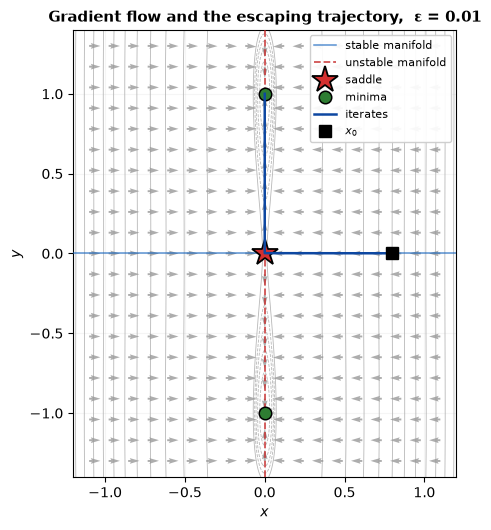

1e-02      blind    converged       1494        640
✓ wrote fig_slow_saddle_flow_eps2.pdf


In [47]:
# `ttl` and a bare `ε` were used here and defined nowhere: the title string and
# the loop variable both live in the shadow notebook and were not carried across.
# The cell already fixes the value it plots as `ε_PLOT`, so use that for both.
# Contour + gradient flow for ONE ε, with the escaping trajectory overlaid
ε_PLOT   = 0.01          # <- change this to plot a different ε
Y0_PANEL = 1e-3

fig_flow = PyPlot.figure(figsize=(5.6, 5.4))
ax = fig_flow.add_subplot(1, 1, 1)

# ---- level sets ----
xg = range(-1.2, 1.2, length=320)
yg = range(-1.4, 1.4, length=340)
Xg = [xi for yi in yg, xi in xg]
Yg = [yi for yi in yg, xi in xg]
Zg = @. 0.5*Xg^2 + ε_PLOT*(Yg^4/4 - Yg^2/2)
lv = sort(vcat(collect(range(-ε_PLOT/4, 0.0, length=6))[1:end-1],
               collect(range(1e-4, 0.7, length=12))))
ax.contour(Xg, Yg, Zg, levels=lv, colors="0.72", linewidths=0.6, zorder=1)

# ---- normalised -grad field ----
xq = range(-1.1, 1.1, length=19)
yq = range(-1.3, 1.3, length=21)
QX = Float64[]; QY = Float64[]; QU = Float64[]; QV = Float64[]
for xi in xq, yi in yq
    gg = -grad_slow([xi, yi], ε_PLOT); n = norm(gg)
    n < 1e-14 && continue
    push!(QX, xi); push!(QY, yi); push!(QU, gg[1]/n); push!(QV, gg[2]/n)
end
ax.quiver(QX, QY, QU, QV, color="0.60", width=0.005, scale=34, alpha=0.8, zorder=2)

# ---- stable / unstable manifolds of the saddle ----
ax.axhline(0.0, color="#1565c0", ls="-",  lw=1.1, alpha=0.7, zorder=3,
           label="stable manifold")
ax.axvline(0.0, color="#c62828", ls="--", lw=1.3, alpha=0.8, zorder=3,
           label="unstable manifold")

# ---- critical points ----
ax.plot([0.0], [0.0], "*", ms=20, mfc="#d32f2f", mec="k", mew=1.3, zorder=6,
        label="saddle")
ax.plot([0.0, 0.0], [1.0, -1.0], "o", ms=9, mfc="#2e7d32", mec="k", mew=1.1,
        zorder=6, label="minima")
m = :blind
h, st, xf = run_slow(ε_PLOT, 1e-3; model=m)
e = escape_k(h)
@printf("%-10.0e %-8s %-11s %8d %10s\n",
        ε_PLOT, string(m), st, length(h.ks), e === nothing ? "---" : string(e))

P = hcat(h.xs...)
stride = max(1, size(P, 2) ÷ 1500)          # thin the near-saddle crawl
idx = unique(vcat(1:stride:size(P,2), size(P,2)))
ax.plot(P[1,idx], P[2,idx], "-", color="#0d47a1", lw=1.8, zorder=7, label="iterates")
ax.plot([P[1,1]], [P[2,1]], "s", ms=8, mfc="k", mec="k", zorder=8, label="\$x_0\$")


ax.set_title(slow_title(ε_PLOT), fontsize=11, fontweight="bold")
ax.set_xlabel("\$x\$"); ax.set_ylabel("\$y\$")
ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.4, 1.4)
ax.set_aspect("equal"); ax.grid(alpha=0.12)
ax.legend(loc="upper right", fontsize=8, framealpha=0.93)

PyPlot.tight_layout()
tag = "eps" * string(round(Int, -log10(ε_PLOT)))     # "eps3" for 1e-3
PyPlot.savefig("fig_slow_saddle_flow_$tag.pdf", bbox_inches="tight")
display(fig_flow)
println("✓ wrote fig_slow_saddle_flow_$tag.pdf")

In [48]:
EPS_SWEEP = [1e-1, 1e-2, 1e-3, 1e-4]
Y0_SWEEP  = [1e-3, 1e-6]
GTHRESH   = 1e-5

slow_rows = Vector{String}[]
println("Escape scaling: k_esc·ε should equal ln(1/y₀)\n")
@printf("%-8s %-8s %-11s %9s %9s %11s %10s %-10s\n",
        "ε", "y₀", "status", "iters", "k_esc", "k_esc·ε", "#|g|<1e-5", "limit")
println("-"^88)
for ε in EPS_SWEEP, y0 in Y0_SWEEP
    h, st, xf = run_slow(ε, y0; model=:blind)
    e    = escape_k(h)
    near = count(<(GTHRESH), h.gs)
    lim  = norm(xf) < 1e-3 ? "SADDLE" : (abs(abs(xf[2]) - 1) < 1e-3 ? "minimiser" : "other")
    @printf("%-8.0e %-8.0e %-11s %9d %9s %11s %10d %-10s\n",
            ε, y0, st, length(h.ks), e === nothing ? "---" : string(e),
            e === nothing ? "---" : @sprintf("%.2f", e*ε), near, lim)
    push!(slow_rows, [sci(ε; d=0), sci(y0; d=0), st, string(length(h.ks)),
                      e === nothing ? "---" : string(e),
                      string(near),
                      lim == "SADDLE" ? "\\textbf{saddle}" : lim])
end
@printf("\nln(1/y₀) = %.3f for y₀ = 1e-3,  %.3f for y₀ = 1e-6\n", log(1e3), log(1e6))
println("The last row TERMINATES AT THE SADDLE: ‖g₀‖ ≈ ε·y₀ = 1e-10 < tol.")

open(io -> latex_table(io,
        [raw"$\varepsilon$", raw"$y_0$", "Status", "Iters", raw"$k_{\mathrm{esc}}$",
         raw"$\#\{\|g_k\|<10^{-5}\}$", "Limit"],
        slow_rows;
        align   = "rrlrrrl",
        caption = raw"Trust-region runs on $f_\varepsilon$ from $x_0=(0.8,y_0)$ under the " *
                  raw"curvature-blind model $B_k=\operatorname{diag}(1,1)$, with truncated CG, " *
                  raw"R-delta, and first-order tolerance $10^{-9}$. The product " *
                  raw"$\varepsilon\,k_{\mathrm{esc}}$ is constant at $\approx\ln(1/y_0)$. The " *
                  raw"final row terminates \emph{at the saddle}, where " *
                  raw"$\|g_0\|\approx\varepsilon y_0=10^{-10}$ is already below tolerance. " *
                  raw"Under the true Hessian every run instead escapes at $k=2$.",
        label   = "tab: slow saddle"),
     "tab_slow_saddle.txt", "w")
println("\n✓ wrote tab_slow_saddle.txt")

Escape scaling: k_esc·ε should equal ln(1/y₀)

ε        y₀       status          iters     k_esc     k_esc·ε  #|g|<1e-5 limit     
----------------------------------------------------------------------------------------
1e-01    1e-03    stagnated         178        67        6.70         63 minimiser 
1e-01    1e-06    stagnated         251       140       14.00        111 minimiser 
1e-02    1e-03    converged        1494       640        6.40        457 minimiser 
1e-02    1e-06    converged        2188      1334       13.34       1150 minimiser 
1e-03    1e-03    converged       13814      6362        6.36       6912 minimiser 
1e-03    1e-06    converged       20725     13273       13.27      13823 minimiser 
1e-04    1e-03    converged      126642     63588        6.36      93094 minimiser 
1e-04    1e-06    converged           3       ---         ---          1 SADDLE    

ln(1/y₀) = 6.908 for y₀ = 1e-3,  13.816 for y₀ = 1e-6
The last row TERMINATES AT THE SADDLE: ‖g₀‖ ≈ ε·y₀ = 

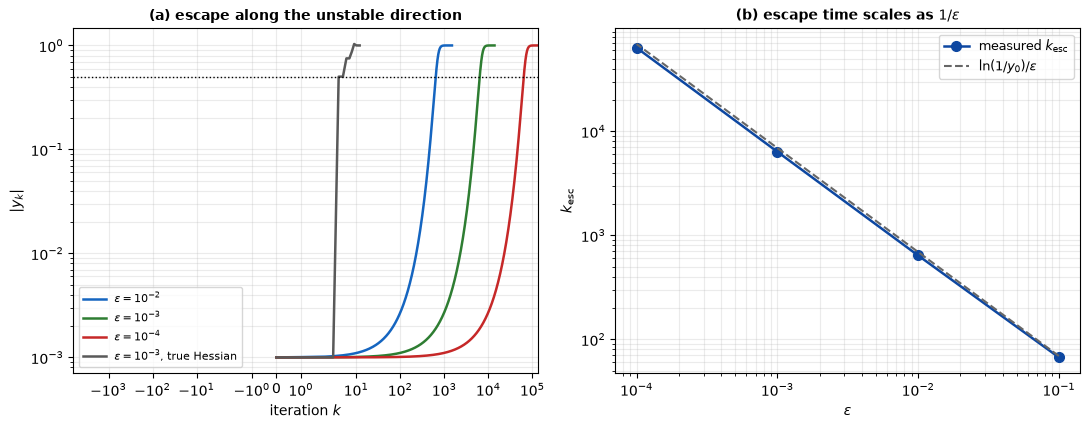

✓ wrote fig12_slow_saddle.pdf


In [49]:
h_a, _, _ = run_slow(1e-2, 1e-3; model=:blind)
h_b, _, _ = run_slow(1e-3, 1e-3; model=:blind)
h_c, _, _ = run_slow(1e-4, 1e-3; model=:blind)
h_t, _, _ = run_slow(1e-3, 1e-3; model=:truehess)

fig_s = PyPlot.figure(figsize=(11.0, 4.4))

axL = fig_s.add_subplot(1, 2, 1)
for (h, lab, col) in [(h_a, "\$\\varepsilon = 10^{-2}\$", "#1565c0"),
                      (h_b, "\$\\varepsilon = 10^{-3}\$", "#2e7d32"),
                      (h_c, "\$\\varepsilon = 10^{-4}\$", "#c62828"),
                      (h_t, "\$\\varepsilon = 10^{-3}\$, true Hessian", "0.35")]
    axL.semilogy(h.ks, max.(abs.([x[2] for x in h.xs]), 1e-18), "-", color=col, lw=1.8, label=lab)
end
axL.axhline(0.5, color="k", ls=":", lw=1.0)
axL.set_xlabel("iteration \$k\$"); axL.set_ylabel("\$|y_k|\$")
axL.set_xscale("symlog"); axL.legend(fontsize=8); axL.grid(alpha=0.25, which="both")
axL.set_title("(a) escape along the unstable direction", fontsize=10, fontweight="bold")

axR = fig_s.add_subplot(1, 2, 2)
εs = EPS_SWEEP
ke = [escape_k(run_slow(ε, 1e-3; model=:blind)[1]) for ε in εs]
axR.loglog(εs, ke, "o-", color="#0d47a1", ms=7, lw=1.8, label="measured \$k_{\\mathrm{esc}}\$")
axR.loglog(εs, log(1e3) ./ εs, "--", color="0.4", lw=1.5,
           label="\$\\ln(1/y_0)/\\varepsilon\$")
axR.set_xlabel("\$\\varepsilon\$"); axR.set_ylabel("\$k_{\\mathrm{esc}}\$")
axR.legend(fontsize=9); axR.grid(alpha=0.25, which="both")
axR.set_title("(b) escape time scales as \$1/\\varepsilon\$", fontsize=10, fontweight="bold")

PyPlot.tight_layout()
PyPlot.savefig("fig12_slow_saddle.pdf", bbox_inches="tight")
display(fig_s)
println("✓ wrote fig12_slow_saddle.pdf")

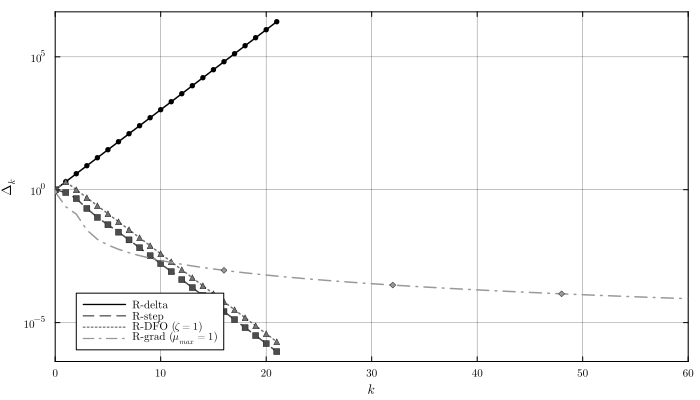

Note: R-delta, R-step and R-DFO terminate within ~20 iterations here;
      R-grad continues to k = 400. The x-axis is clipped to 60 to keep
      the short runs legible — widen XLIM_FIG2 to see R-grad's full decay.
✓ wrote fig2_radius_per_rule.pdf


In [51]:
# ---------------- Figure 2: radius versus iteration, per mechanism ----------------
KMAX_FIG2 = 400
XLIM_FIG2 = 60          # the blind rules finish in ~20 iterations; R-grad runs on

p2 = Plots.plot(xlabel = L"k", ylabel = L"\Delta_k", yscale = :log10, legend = :bottomleft,
          xlims = (0, XLIM_FIG2))

rules_fig = [(RDelta(),        "R-delta",        :solid,   :circle,  :black),
             (RStep(),         "R-step",         :dash,    :square,  :gray30),
             (RDFO(ζ=1.0),     L"R-DFO ($\zeta=1$)",   :dot,     :utriangle, :gray45),
             (rgrad_capped(1.0), L"R-grad ($\mu_{max}=1$)", :dashdot, :diamond, :gray60)]

for (R, lab, ls, mk, col) in rules_fig
    rws, st, xf = run_tr(X0_FIG; radius=R, model=TrueHessian(), solver=:cg,
                         kmax=KMAX_FIG2, tol=1e-12)
    ks = [r.k for r in rws]; Δs = [r.Δ for r in rws]
    # draw the full curve, but only mark a subsample so the markers stay legible
    step = max(1, length(ks) ÷ 25)
    idx  = 1:step:length(ks)
    Plots.plot!(p2, ks, Δs, label = lab, linestyle = ls, color = col, linewidth = 1.5)
    Plots.scatter!(p2, ks[idx], Δs[idx], label = "", marker = mk, color = col,
             markersize = 3.0, markerstrokewidth = 0.5)
end

println("Note: R-delta, R-step and R-DFO terminate within ~20 iterations here;")
println("      R-grad continues to k = $KMAX_FIG2. The x-axis is clipped to $XLIM_FIG2 to keep")
println("      the short runs legible \u2014 widen XLIM_FIG2 to see R-grad's full decay.")

Plots.savefig(p2, "fig2_radius_per_rule.pdf")
display(p2)
println("✓ wrote fig2_radius_per_rule.pdf")

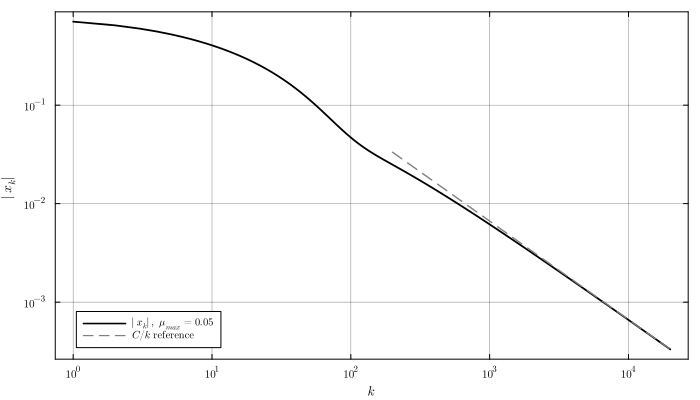

crawl: max_iter after 20000 iterations, limit other, |x| = 3.315e-04
✓ wrote fig3_sublinear_crawl.pdf


In [52]:
# ---------------- Figure 3: the sublinear crawl ----------------
# `rows_crawl` was never produced in this notebook: the run that fills it lives in
# the shadow. Reproduced here through the package, with the same configuration the
# label below states, mu_max = 0.05 from the crawl start.
const MU_CRAWL = 0.05
const X0_CRAWL = [-0.5, 0.6]
rows_crawl, st_crawl, xf_crawl =
    run_tr(X0_CRAWL; radius = rgrad_capped(MU_CRAWL), model = ExactHessian(),
           solver = :cg, kmax = 20_000, tol = 1e-10)
@printf("crawl: %s after %d iterations, limit %s, |x| = %.3e
",
        st_crawl, length(rows_crawl) - 1, which_crit(xf_crawl), norm(xf_crawl))

ks_c  = [r.k for r in rows_crawl if r.k >= 1]
nrm_c = [norm(r.x) for r in rows_crawl if r.k >= 1]

p3 = Plots.plot(xlabel = L"k", ylabel = L"\|x_k\|", xscale = :log10, yscale = :log10,
          legend = :bottomleft)
Plots.plot!(p3, ks_c, nrm_c, label = L"\|x_k\|,\ \mu_{max} = 0.05",
      color = :black, linewidth = 1.8, marker = :none)
kk = ks_c[max(1, length(ks_c) ÷ 100):end]
Plots.plot!(p3, kk, 6.65 ./ kk, label = L"C/k\ \mathrm{reference}",
      color = :gray50, linestyle = :dash, linewidth = 1.4)

Plots.savefig(p3, "fig3_sublinear_crawl.pdf")
display(p3)
println("✓ wrote fig3_sublinear_crawl.pdf")

## 13. What the matrix shows

**The limit is set by the model, not by the radius rule.** Across the whole configuration matrix
the radius mechanism never changes which critical point is reached. It changes how fast, and
sometimes whether the run terminates cleanly, but the three distinct limits — degenerate origin,
local minimiser, saddle — track the three model choices. This is structural rather than accidental:
the radius rule chooses the *length* of $s_k$, while its *direction* is dictated by $B_k$.

**Small $\mu_{\max}$ silently converts the method into gradient descent.** With truncated CG and a
small cap, CG never gets past its first iteration, so the step is the Cauchy point and $B_k$ enters
only through $\rho_k$. The method stops being a trust-region method in any meaningful sense and
inherits gradient-descent asymptotics — here a sublinear $\Theta(1/k)$ crawl into a degenerate
point.

With quasi-Newton models this is not merely a slowdown. §10 exhibits a **threshold** near
$\mu_{\max} \approx 0.5$: below it the accumulated curvature is never used for direction and the
run reaches the degenerate origin, where $\lambda_{\min}(\nabla^2 f) = 0$ and the limit is not a
minimiser; above it the curvature enters the step and the run reaches a genuine local minimiser in
a few dozen iterations. Any bound $\mu_k \le \overline{\mu}$ needed for the asymptotic theory must
therefore be read as an *upper* bound whose smallness changes not just the rate but the
**destination**.

**First-order theory is not violated anywhere.** In the SPD-model runs every hypothesis holds and
every conclusion is correct: $f$ decreases monotonically, every $\rho_k$ is successful,
$\|g_k\| \to 0$, the iterates converge, the radius behaves impeccably. And the limit is a saddle.
The second-order criticality measure $\tau(x) = \max\{\|g\|,-\lambda^-\}$ catches this **only**
when $\lambda^-$ is the leftmost eigenvalue of the *true* Hessian; evaluated on the model,
$\lambda_{\min}(B_k) > 0$ always and $\tau$ reports convergence.

**And $\tau$ is not sufficient either.** The origin, which is where most configurations actually
land, has $\tau = 0$ exactly: $\nabla^2 f(0,0) = \operatorname{diag}(0,\tfrac12)$ is singular and
positive semidefinite. Yet $f(x,0) = x^3(x-1) < 0$ for small $x > 0$, so it is not a local
minimiser. A second-order measure certifies a point that is not a minimum, because the deciding
information is third order.

In [53]:
println("Files written:\n")
for fn in ["tab_config_matrix.txt", "tab_rgrad_mumax.txt", "tab_crawl.txt",
           "tab_rdfo_zeta.txt", "tab_mumax_threshold.txt",
           "tab_spd_saddle.txt", "tab_spd_all_rules.txt",
           "fig1_phase_portrait.pdf", "fig2_radius_per_rule.pdf",
           "fig3_sublinear_crawl.pdf"]
    @printf("  %-28s %s\n", fn, isfile(fn) ? "✓" : "(not yet generated)")
end
println("\nTables are complete booktabs environments: paste directly, or rename to .tex and \\input.")
println("Preamble needs \\usepackage{booktabs}.")

Files written:

  tab_config_matrix.txt        (not yet generated)
  tab_rgrad_mumax.txt          (not yet generated)
  tab_crawl.txt                (not yet generated)
  tab_rdfo_zeta.txt            (not yet generated)
  tab_mumax_threshold.txt      (not yet generated)
  tab_spd_saddle.txt           (not yet generated)
  tab_spd_all_rules.txt        (not yet generated)
  fig1_phase_portrait.pdf      ✓
  fig2_radius_per_rule.pdf     ✓
  fig3_sublinear_crawl.pdf     ✓

Tables are complete booktabs environments: paste directly, or rename to .tex and \input.
Preamble needs \usepackage{booktabs}.


In [54]:
# Discussion on the trust-region radius mechanisms R-DFO and R-grad
#
# Inactivity, and the influence of ζ and μ_max on the convergence rate.
# (These three lines were prose pasted into a code cell without comment
# markers, so this cell raised UndefVarError: `What` not defined.)

# ================================================================
# κ̄ = 4/λ_min* and the trust-region radius: f(x,y) = sin(x)/x + y²
# ================================================================
sinc(x)   = abs(x) < 1e-10 ? 1.0 : sin(x)/x
f_sc(p)   = sinc(p[1]) + p[2]^2
function grad_sc(p)
    x, y = p
    gx = abs(x) < 1e-8 ? 0.0 : (x*cos(x) - sin(x))/x^2
    return [gx, 2y]
end
function hess_sc(p)
    x, y = p
    gxx = abs(x) < 1e-6 ? -1/3 :
          -sin(x)/x - 2cos(x)/x^2 + 2sin(x)/x^3
    return [gxx 0.0; 0.0 2.0]
end

# Target: the positive-definite critical point (minimiser in x) at tan x = x, x ≈ 10.904.
const XSTAR_SC = [10.9041216594289, 0.0]
const LMIN_SC  = hess_sc(XSTAR_SC)[1,1]           # = 0.09133
# κ̄ from the package rather than hand-rolled. `kappa_bar` now defaults to
# :neighbourhood (8/λ*_min), the convention Part III quotes; :eigenvalue is the
# 4/λ*_min this line used to hard-code. Both are printed so the factor of two
# is visible rather than implied.
const KAPPA_SC     = kappa_bar(LMIN_SC; convention = :eigenvalue)   # 4/λ*_min ≈ 43.8
const KAPPA_SC_NBH = kappa_bar(LMIN_SC)                             # 8/λ*_min ≈ 87.6

@printf("Target x* = (%.5f, 0),  f(x*) = %.6f\n", XSTAR_SC[1], f_sc(XSTAR_SC))
@printf("eig ∇²f(x*) = (%.5f, %.1f)  =>  λ_min* = %.5f\n",
        LMIN_SC, hess_sc(XSTAR_SC)[2,2], LMIN_SC)
@printf("κ̄ = 4/λ_min* = %.2f\n", KAPPA_SC)


Target x* = (10.90412, 0),  f(x*) = -0.091325
eig ∇²f(x*) = (0.09133, 2.0)  =>  λ_min* = 0.09133
κ̄ = 4/λ_min* = 43.80


In [55]:

# --- self-contained driver recording everything the plots need ---
Base.@kwdef struct RowSC
    k::Int; x::Vector{Float64}; f::Float64; gn::Float64
    Δ::Float64; ρ::Float64; ns::Float64; active::Bool
end

"Steihaug–Toint truncated CG (local copy so this section stands alone)."
function cg_sc(g, B, Δ; tol=1e-12, maxit=50)
    z = zeros(2); r = copy(g); d = -r
    norm(r) < tol && return z, false
    for _ in 1:maxit
        dBd = dot(d, B*d)
        if dBd <= 0
            aa=dot(d,d); bb=2dot(z,d); cc=dot(z,z)-Δ^2
            return z + (-bb+sqrt(bb^2-4aa*cc))/(2aa)*d, true
        end
        α = dot(r,r)/dBd; zn = z + α*d
        if norm(zn) >= Δ
            aa=dot(d,d); bb=2dot(z,d); cc=dot(z,z)-Δ^2
            return z + (-bb+sqrt(bb^2-4aa*cc))/(2aa)*d, true
        end
        rn = r + α*(B*d)
        norm(rn) < tol*norm(g) && return zn, false
        d = -rn + (dot(rn,rn)/dot(r,r))*d; z = zn; r = rn
    end
    return z, false
end

"""
    run_sc(x0; rule, ζ, μmax, Δ0, kmax, tol) -> (rows, status, xfinal)

Trust-region on f_sc with the true Hessian and truncated CG.
`rule ∈ (:rdelta, :rdfo, :rgrad)`.
"""
function run_sc(x0; rule::Symbol, ζ=nothing, μmax=nothing, Δ0=0.03,
                kmax=4000, tol=1e-9, η=1e-4, η1=0.25, η2=0.75,
                γ1=0.25, γ2=0.5, γ3=2.0, Δmax=1e3)
    x = collect(float.(x0))
    μ = μmax
    Δ = rule === :rgrad ? μ*norm(grad_sc(x)) : Δ0
    rows = RowSC[]; status = "maxiter"
    for k in 0:kmax-1
        g = grad_sc(x); gn = norm(g); fk = f_sc(x)
        rule === :rgrad && (Δ = μ*gn)
        if gn < tol
            status = "converged"
            push!(rows, RowSC(k=k, x=copy(x), f=fk, gn=gn, Δ=Δ, ρ=NaN, ns=NaN, active=false))
            break
        end
        B = hess_sc(x)
        s, act = cg_sc(g, B, Δ)
        pred = -(dot(g,s) + 0.5*dot(s, B*s))
        ared = fk - f_sc(x .+ s)
        ρ = pred > 1e-300 ? ared/pred : -Inf
        push!(rows, RowSC(k=k, x=copy(x), f=fk, gn=gn, Δ=Δ, ρ=ρ, ns=norm(s), active=act))
        ρ >= η && (x = x .+ s)
        if rule === :rdelta
            Δ = ρ < η1 ? γ1*Δ : (ρ >= η2 ? min(γ3*Δ, Δmax) : Δ)
        elseif rule === :rdfo
            Δ = ρ < η1 ? γ1*Δ : (Δ > ζ*gn ? γ2*Δ : min(γ3*Δ, Δmax))
        else  # :rgrad
            μ = ρ < η1 ? γ1*μ : (ρ < η2 ? γ2*μ : min(γ3*μ, μmax))
        end
    end
    return rows, status, x
end

# --- the five configurations, straddling κ̄ ≈ 43.8 ---
X0_SC = [9.6, 0.4]
configs = [("R-DFO, ζ = 60 > κ̄",      (rule=:rdfo,  ζ=60.0),  "#1565c0", "-"),
           ("R-DFO, ζ = 0.5 ≪ κ̄",     (rule=:rdfo,  ζ=0.5),   "#c62828", "--"),
           ("R-grad, μmax = 50 > κ̄",   (rule=:rgrad, μmax=50.0),"#2e7d32", "-"),
           ("R-grad, μmax = 1 ≪ κ̄",    (rule=:rgrad, μmax=1.0), "#ef6c00", "--"),
           ("R-delta",                  (rule=:rdelta,),        "0.35",    "-.")]

results = Tuple{String,Vector{RowSC},String,String,String}[]
println("\nFive configurations from x0 = ", X0_SC, ",  κ̄ = ", round(KAPPA_SC, digits=2), "\n")
@printf("%-24s %-11s %7s %10s %12s\n", "config", "status", "iters", "#active", "dist to x*")
println("-"^70)
for (lab, kw, col, ls) in configs
    rows, st, xf = run_sc(X0_SC; kw...)
    nact = count(r -> r.active, rows)
    @printf("%-24s %-11s %7d %10d %12.2e\n",
            lab, st, rows[end].k, nact, norm(xf .- XSTAR_SC))
    push!(results, (lab, rows, col, ls, st))
end
println("\nOnly the two ≪ κ̄ runs keep the trust region active indefinitely:")
println("for R-DFO the contraction branch needs Δ > ζ‖g‖, and for R-grad μ is capped")
println("below κ̄, so Δ = μ‖g‖ can never reach ‖s‖ — both crawl with the constraint binding.")


Five configurations from x0 = [9.6, 0.4],  κ̄ = 43.8

config                   status        iters    #active   dist to x*
----------------------------------------------------------------------
R-DFO, ζ = 60 > κ̄        converged         9          5     1.78e-15
R-DFO, ζ = 0.5 ≪ κ̄       maxiter        3999       4000     5.98e-08
R-grad, μmax = 50 > κ̄    converged         6          1     1.78e-15
R-grad, μmax = 1 ≪ κ̄     maxiter        3999       4000     3.98e-08
R-delta                  converged         9          5     1.78e-15

Only the two ≪ κ̄ runs keep the trust region active indefinitely:
for R-DFO the contraction branch needs Δ > ζ‖g‖, and for R-grad μ is capped
below κ̄, so Δ = μ‖g‖ can never reach ‖s‖ — both crawl with the constraint binding.


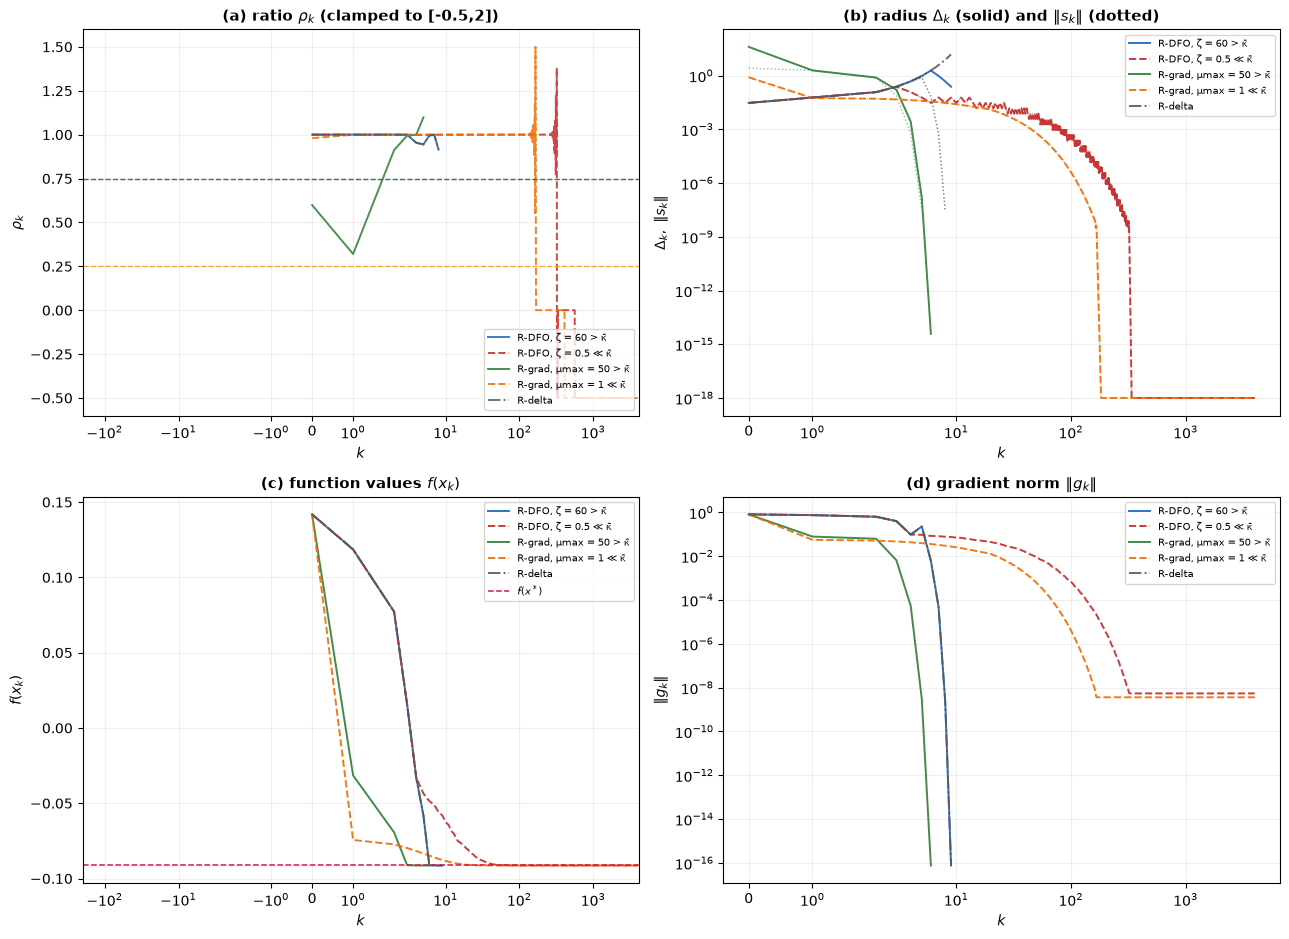

✓ wrote fig_kappa_diagnostics.pdf


In [56]:
# --- four diagnostic panels: ρ, (Δ, ‖s‖), f, ‖g‖ ---
fig_sc = PyPlot.figure(figsize=(13.0, 9.5))
axρ = fig_sc.add_subplot(2, 2, 1)
axΔ = fig_sc.add_subplot(2, 2, 2)
axf = fig_sc.add_subplot(2, 2, 3)
axg = fig_sc.add_subplot(2, 2, 4)

for (lab, rows, col, ls, st) in results
    K  = [r.k for r in rows]
    # (a) ρ_k — scatter, since the crawling runs have thousands of points
    KR = [r.k for r in rows if !isnan(r.ρ)]
    R  = [clamp(r.ρ, -0.5, 2.0) for r in rows if !isnan(r.ρ)]
    axρ.plot(KR, R, ls, color=col, lw=1.4, alpha=0.85, label=lab)
    # (b) Δ_k solid, ‖s_k‖ faint — log scale
    axΔ.semilogy(K, max.([r.Δ for r in rows], 1e-18), ls, color=col, lw=1.4, alpha=0.9, label=lab)
    Ks = [r.k for r in rows if !isnan(r.ns)]
    sv = [max(r.ns, 1e-18) for r in rows if !isnan(r.ns)]
    axΔ.semilogy(Ks, sv, ":", color=col, lw=1.0, alpha=0.5)
    # (c) f_k
    axf.plot(K, [r.f for r in rows], ls, color=col, lw=1.4, alpha=0.9, label=lab)
    # (d) ‖g_k‖ — log scale
    axg.semilogy(K, max.([r.gn for r in rows], 1e-18), ls, color=col, lw=1.4, alpha=0.9, label=lab)
end

axρ.axhline(0.75, color="#2e7d32", ls="--", lw=1.0); axρ.axhline(0.25, color="#f9a825", ls="--", lw=1.0)
axρ.set_title("(a) ratio \$\\rho_k\$ (clamped to [-0.5,2])", fontsize=11, fontweight="bold")
axρ.set_xlabel("\$k\$"); axρ.set_ylabel("\$\\rho_k\$"); axρ.set_xscale("symlog")
axρ.legend(fontsize=7.5, loc="lower right"); axρ.grid(alpha=0.2)

axΔ.set_title("(b) radius \$\\Delta_k\$ (solid) and \$\\|s_k\\|\$ (dotted)", fontsize=11, fontweight="bold")
axΔ.set_xlabel("\$k\$"); axΔ.set_ylabel("\$\\Delta_k,\\ \\|s_k\\|\$"); axΔ.set_xscale("symlog")
axΔ.legend(fontsize=7.5); axΔ.grid(alpha=0.2, which="both")

axf.axhline(f_sc(XSTAR_SC), color="crimson", ls="--", lw=1.1, label="\$f(x^*)\$")
axf.set_title("(c) function values \$f(x_k)\$", fontsize=11, fontweight="bold")
axf.set_xlabel("\$k\$"); axf.set_ylabel("\$f(x_k)\$"); axf.set_xscale("symlog")
axf.legend(fontsize=7.5); axf.grid(alpha=0.2)

axg.set_title("(d) gradient norm \$\\|g_k\\|\$", fontsize=11, fontweight="bold")
axg.set_xlabel("\$k\$"); axg.set_ylabel("\$\\|g_k\\|\$"); axg.set_xscale("symlog")
axg.legend(fontsize=7.5); axg.grid(alpha=0.2, which="both")

PyPlot.tight_layout()
PyPlot.savefig("fig_kappa_diagnostics.pdf", bbox_inches="tight")
display(fig_sc)
println("✓ wrote fig_kappa_diagnostics.pdf")

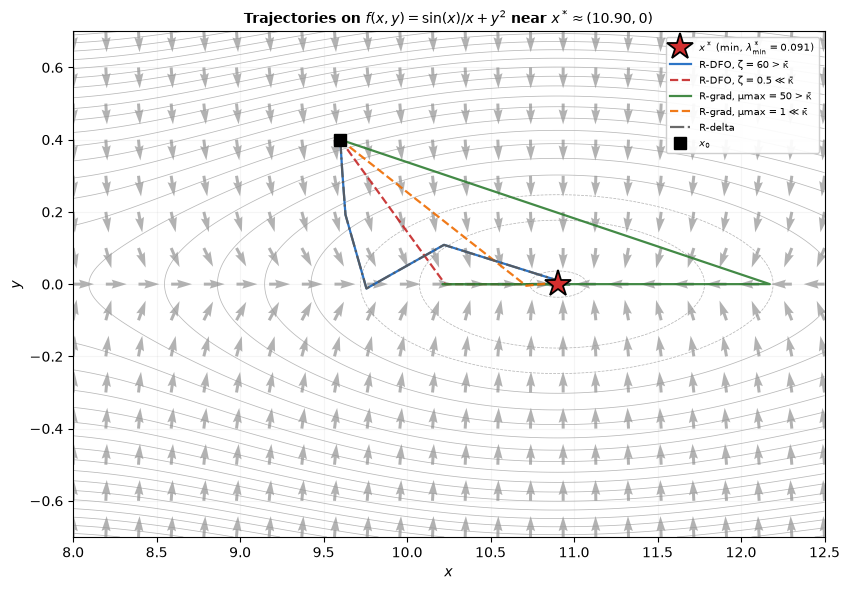

✓ wrote fig_kappa_trajectories.pdf


In [57]:
# --- trajectories over contour + gradient flow ---
fig_tr = PyPlot.figure(figsize=(8.6, 6.0))
ax = fig_tr.add_subplot(1, 1, 1)

xg = range(8.0, 12.5, length=360)
yg = range(-0.7, 0.7, length=280)
Xg = [xi for yi in yg, xi in xg]
Yg = [yi for yi in yg, xi in xg]
Zg = [f_sc([Xg[i], Yg[i]]) for i in eachindex(Xg)]
Zg = reshape(Zg, size(Xg))
ax.contour(Xg, Yg, Zg, levels=25, colors="0.72", linewidths=0.55, zorder=1)

xq = range(8.0, 12.5, length=24); yq = range(-0.7, 0.7, length=15)
QX=Float64[]; QY=Float64[]; QU=Float64[]; QV=Float64[]
for xi in xq, yi in yq
    gg = -grad_sc([xi, yi]); n = norm(gg)
    n < 1e-14 && continue
    push!(QX, xi); push!(QY, yi); push!(QU, gg[1]/n); push!(QV, gg[2]/n)
end
ax.quiver(QX, QY, QU, QV, color="0.60", width=0.004, scale=36, alpha=0.75, zorder=2)

# neighbouring saddles at x ≈ 7.73 and 14.07 lie off-frame; mark x* and start
ax.plot([XSTAR_SC[1]], [XSTAR_SC[2]], "*", ms=20, mfc="#d32f2f", mec="k", mew=1.3,
        zorder=7, label="\$x^*\$ (min, \$\\lambda_{\\min}^* = " *
                        @sprintf("%.3f", LMIN_SC) * "\$)")

for (lab, rows, col, ls, st) in results
    P = hcat([r.x for r in rows]...)
    stride = max(1, size(P,2) ÷ 300)
    idx = unique(vcat(1:stride:size(P,2), size(P,2)))
    ax.plot(P[1,idx], P[2,idx], ls, color=col, lw=1.6, alpha=0.9, zorder=6, label=lab)
end
ax.plot([X0_SC[1]], [X0_SC[2]], "s", ms=9, mfc="k", mec="k", zorder=8, label="\$x_0\$")

ax.set_title("Trajectories on \$f(x,y)=\\sin(x)/x + y^2\$ near \$x^*\\approx(10.90,0)\$",
             fontsize=10, fontweight="bold")
ax.set_xlabel("\$x\$"); ax.set_ylabel("\$y\$")
ax.set_xlim(8.0, 12.5); ax.set_ylim(-0.7, 0.7)
ax.legend(fontsize=7.5, loc="upper right", framealpha=0.93); ax.grid(alpha=0.12)

PyPlot.tight_layout()
PyPlot.savefig("fig_kappa_trajectories.pdf", bbox_inches="tight")
display(fig_tr)
println("✓ wrote fig_kappa_trajectories.pdf")